Max Xia

# How Are Continuous Motor Skills Learned and Represented

## Background

From calligraphy to Formula 1 racing, real-world motor skills require continuous actions that are planned and executed with both speed and precision - proficiency forged through practice. Prior work on discrete or sequential actions (e.g., reaching or keypress sequences) observed learning involves multiple process: (i) **sequence-specific gains** that arise from improved predictions of upcoming elements (Kashefi et al., 2024; Kashefi et al., 2025), (ii) **general execution and planning improvements** (Ariani et al., 2021; Bashford et al., 2022). However, whether these processes extend to continuous, real-world skills learning remains unclear.

To fill this gap, we asked two questions. First, how does continuous motor performance improve with practice? Building on the previous literature, we hypothesize that improvements also reflect **trajectory-specific** and **general** improvements in planning and execution. Second, how are learned motor skills represented? We hypothesize that learning leverages a representation of **global structure** (i.e., the continuous trajectory’s shape), not merely a sequence of individual movements. 

## Variables

### Data collection

We recruited a large sample of participants ($N = 300$) via Prolific to complete a [web-based tracing task](https://sequential-learning.web.app/). On each trial, participants traced a 2D trajectory with a cursor as quickly and accurately as possible.

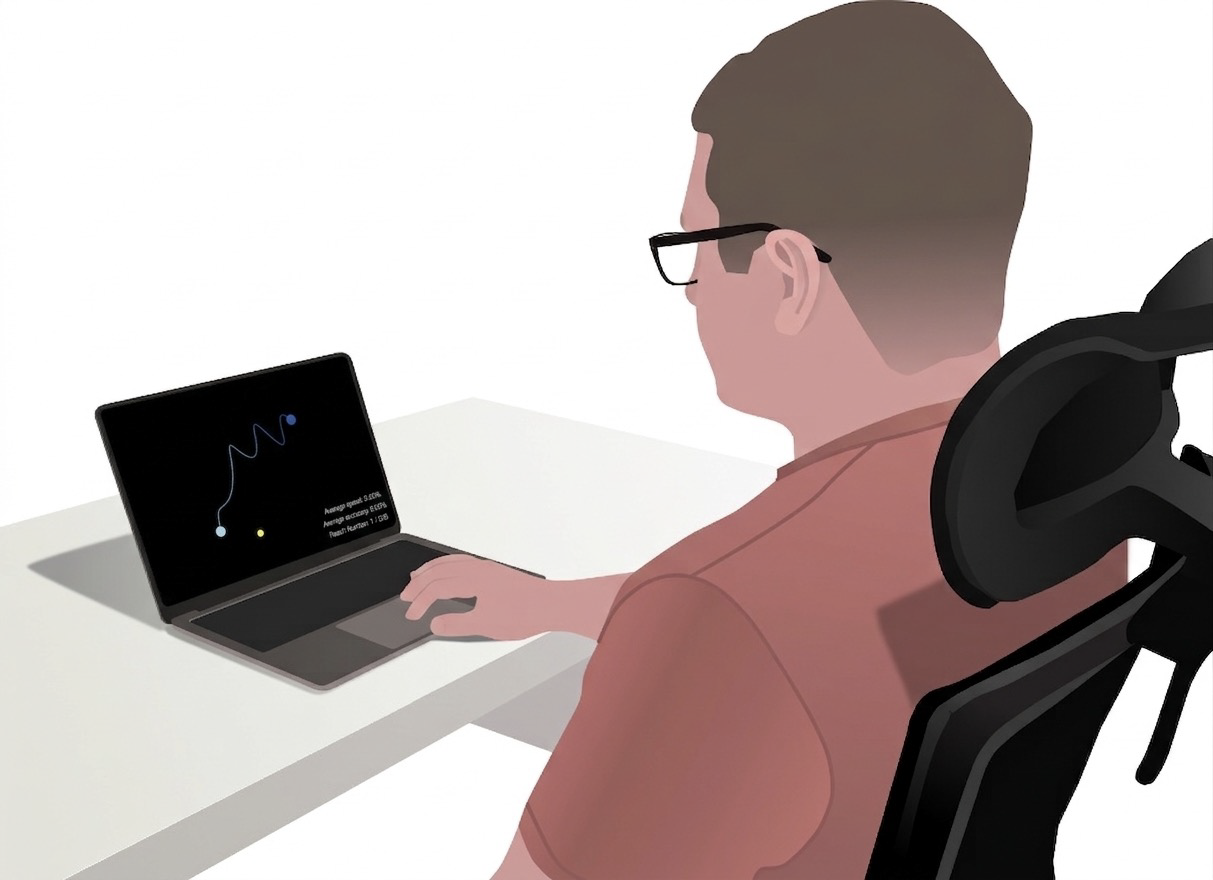

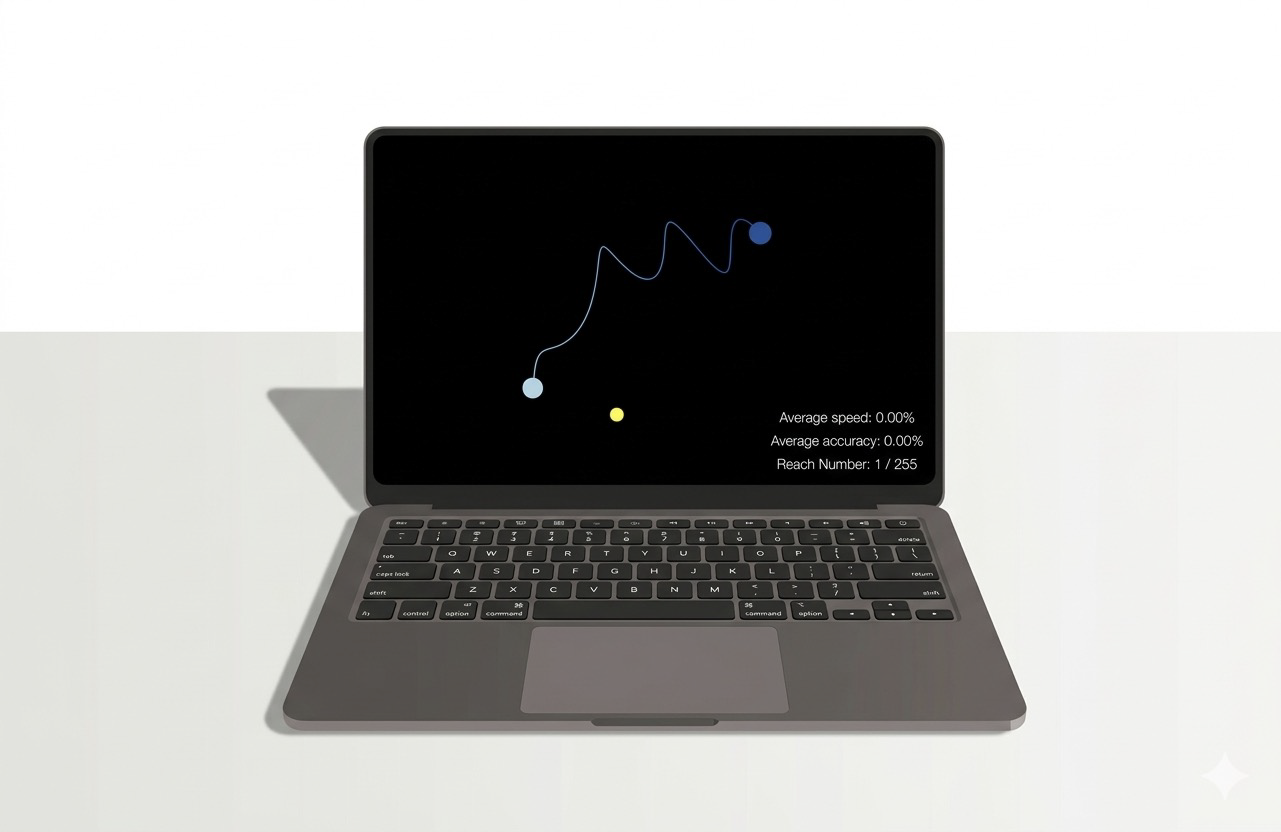

Participants were randomly assigned to one of five preview conditions ($n = 60$ /group), which manipulated how much of the upcoming trajectory was visible. In the full-preview condition (100\%), the entire path was shown; in reduced-preview conditions (5\%, 10\%, 25\%, 50\%), only a limited segment ahead of the cursor was visible, akin to navigating with a flashlight in the dark.

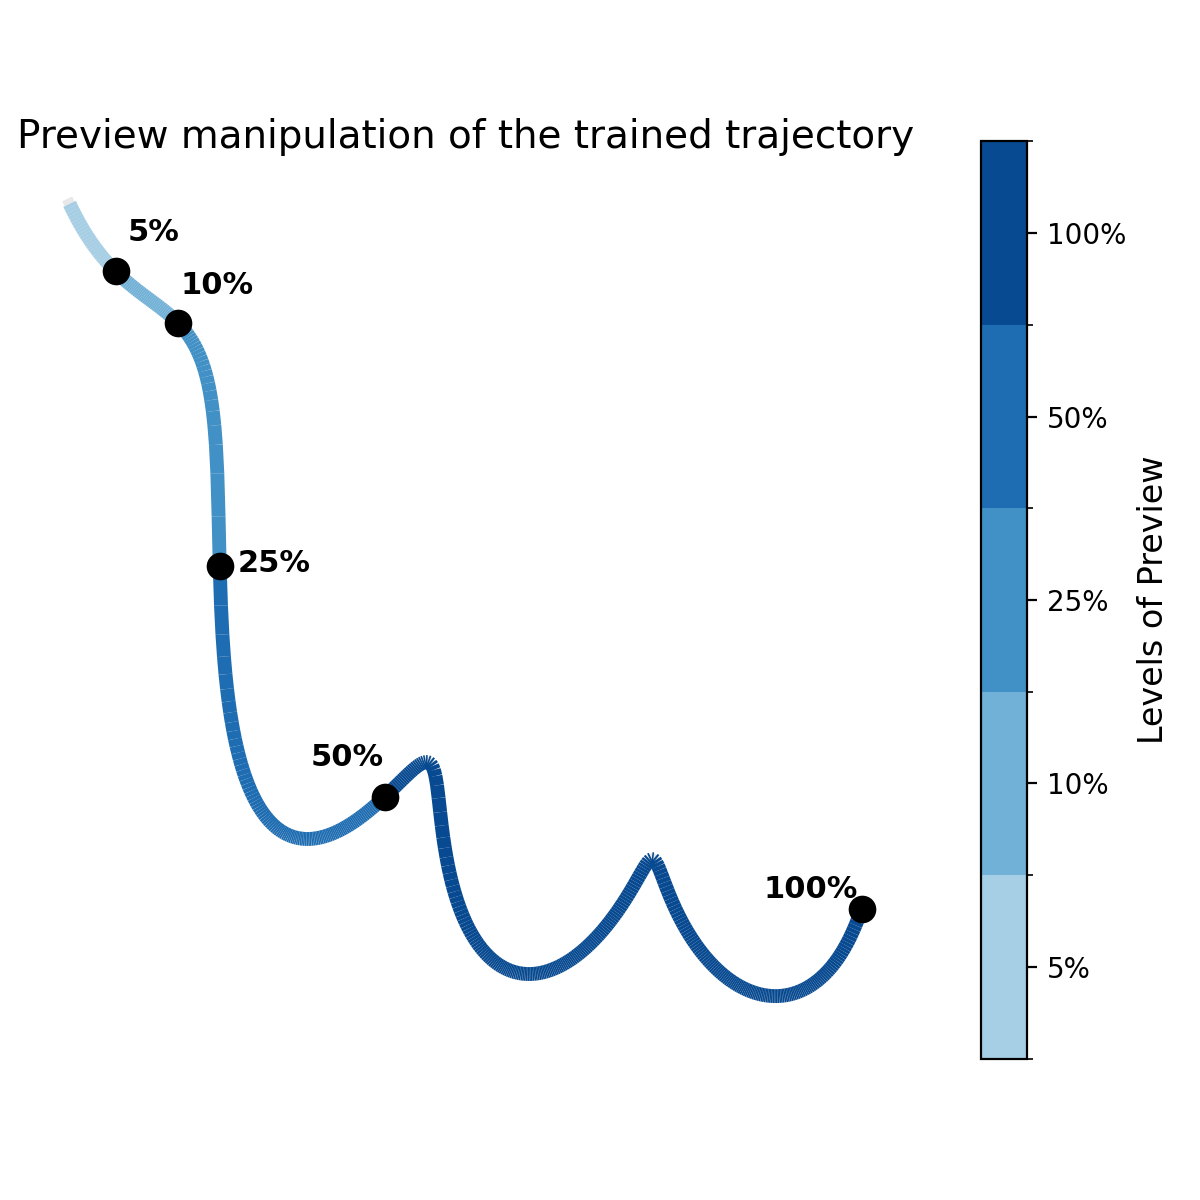

### Variables

The experiment consisted of 45 cycles (240 trials). Each cycle included four repetitions of the trained trajectory (180 trials), one random trajectory (45 trials), and rotated versions of the trained trajectory (presented with one-third probability across cycles; 15 trials). Trajectories were generated using a sum-of-sines algorithm (amplitude: 0.5-1.5; frequency: 0.4-0.6 (Yang et al., 2021), with all paths matched in length):

$$x(t) = \sum_{k=1}^{N} A_k \cos(2\pi w_k t + \phi_k)$$
$$y(t) = \sum_{k=1}^{N} B_k \cos(2\pi v_k t + \psi_k)$$

$t$: The time parameter, ranging from $0$ to $T$ (T = 3.0 seconds).

$N$: The number of Fourier terms defining the curve complexity (N = 4).

$A_k, B_k$: Random amplitudes uniformly sampled between amp_min and amp_max.

$w_k, v_k$: Random frequencies uniformly sampled between freq_min and freq_max.

$\phi_k, \psi_k$: Random phase offsets uniformly sampled between $0$ and $2\pi$.


$$\mathbf{r}(t) = \begin{bmatrix} \sum_{k=1}^{N} A_k \cos(2\pi w_k t + \phi_k) \\ \sum_{k=1}^{N} B_k \cos(2\pi v_k t + \psi_k) \end{bmatrix}$$

#### Independent Variables (Predictors):

**Preview Condition** (`condition`): Categorical/Ordinal variable representing the percentage of the upcoming trajectory visible to the participant (5%, 10%, 25%, 50%, 100%).

- The difference between 5% and 100% is about whether they have the knowledge of what comes next. So if prediction drives learning, then we should see a huge improvement on 5%, because 5% preview forces participants to learn what comes next, while for 100% preview, since they have full visibility, performance should be near the ceiling from the start, with little room for improvement.

**Trajectory Type** (`traj_type`): Categorical variable denoting the type of path traced in a given trial (Trained `learned`, Random `random`, or Rotated `rotated`).

- Trained trajectory: The same trajectory was repeatedly shown across the experiment
- Random trajectory: Interleaved with the trained trajectory. There is no repetition of them; every single trajectory is different
- Rotated trajectorie: Rotated versions of the trained trajectory, and no rotation angle was repeated

**Stage** (`stage`): Categorical variable distinguishing the process of learning for the whole experiment (first one-third: early `EARLY`; last one-third: late `LATE`)

**Trial Number** (`trial_index`): Integer variable representing the learning progression across the 45 cycles (`cycle`) (240 total trials).

#### Dependent Variables (Outcomes):

**Movement Time** (`MT`): Continuous float representing the interval from the start to the end position.

**Spatial Error** (`ERROR`): Continuous float representing the mean Euclidean distance between the participant’s path and the target trajectory (resampled to 200 evenly spaced points).

**Movement Smoothness** (`LDJ`): Continuous float representing the magnitude of jerk (rate of change of acceleration), normalized for movement duration and amplitude. 

## Hypotheses

We will evaluate our research questions using Mixed-Design ANOVAs and Paired-Samples t-tests.

Let $Y$ represent our primary continuous dependent metrics: $Y_{MT}$ (Movement Time, in seconds), $Y_{ERROR}$ (Spatial Error, in a.u.), or $Y_{LDJ}$ (Movement Smoothness/Log-Dimensionless Jerk, in a.u.).

## Research Question 1: *How do continuous motor skills improve with practice?*
###  **Hypothesis 1: Trajectory-Specific and General Improvements Learning over Time**

We hypothesize that performance improves with practice (from Early to Late stages) through two distinct mechanisms: general motor improvements and trajectory-specific anticipation.

#### Sub-Hypothesis 1a: Trajectory-specific learning improved predictions of future movements, with strong modulation by preview conditions

We hypothesize that participants acquire trajectory-specific predictions of upcoming movements. Consequently, by the end of practice, performance on the Learned trajectory will be significantly better than on the Random trajectory.

Furthermore, we hypothesize that the magnitude of this trajectory-specific advantage is strongly modulated by the visual preview window (i.e., highly restricted previews force greater reliance on memory).

Analytical Model (Mixed ANOVA): We evaluated this using a 2-Way Mixed-Design ANOVA restricted to the Late stage of learning.

- Within-Subjects Factor: $Trajectory\_Type$ (Learned vs. Random)
- Between-Subjects Factor: $Condition$ (Preview window: 5%, 10%, 25%, 50%, 100%)
- Formula: $Y_{Late} \sim Trajectory\_Type + Condition + (Trajectory\_Type \times Condition)$

Analysis (Predictive Lag): To directly quantify these predictive mechanisms, we used **Cross-Correlation** to measure the temporal lag between the target and cursor trajectories across learning stages.

#### Sub-Hypothesis 1b: General skill improvements reflect increase motor efficiency rather than an expansion of planning capacity

We hypothesize that general skill improvements (gains seen on random trajectories) reflect an increase in continuous motor efficiency, rather than an expansion of the underlying planning capacity (planning horizon). Therefore, performance on purely random, unpracticed trajectories will improve from the Early to Late stages of learning.

Analytical Model (Mixed ANOVA): We evaluated general learning using a 2-Way Mixed-Design ANOVA restricted to Random trajectories.

- Within-Subjects Factor: $Stage$ (Early vs. Late)
- Between-Subjects Factor: $Condition$ (Preview window: 5%, 10%, 25%, 50%, 100%)
- Formula: $Y_{Random} \sim Stage + Condition + (Stage \times Condition)$

Analysis: We used **Bootstrapping** to estimate the confidence intervals of generalized performance gains across varying preview conditions to confirm whether general baseline improvements remain consistent regardless of how much visual information is provided.

## Research Question 2: *How are learned motor skills represented?*
### **Hypothesis 2: Global Shape Representation (Transfer)**

We hypothesize that learned continuous skills are encoded as global structural representations rather than rigid, sequence-specific motor plans. Consequently, participants will exhibit positive transfer of learning, performing significantly better on structurally identical but spatially manipulated (Rotated) versions of the trained trajectory compared to completely Random probe trajectories.

Analytical Model (Paired t-tests): We will evaluate transfer of learning exclusively during the Late stage using within-subjects paired t-tests (and Cohen's d for effect size).

- Comparison: $Y_{Rotated}$ vs. $Y_{Random}$

(Evaluated only on Late stage data, where $Trajectory\_Type \in \{rotated, random\}$)

## Data Organization

### Data Architecture:

The raw data is parsed from multiple CSV files representing different visual preview cohorts (5vision, 10vision, 25vision, 50vision, 100vision).

The data features a nested, hierarchical architecture: Condition $\rightarrow$ Subject $\rightarrow$ Stage $\rightarrow$ Trial $\rightarrow$ Spatial Time-Series. Each row in the raw dataset corresponds to a single continuous tracing trial, storing both scalar execution metrics and high-dimensional arrays containing the X/Y spatial coordinates of both the target and the user's cursor.

### Data Cleansing & Tidying:

1. Format Unwrapping: 

Extraneous array brackets generated during Firestore database logging were collapsed into scalar values (using custom unwrap functions) to ensure tidy-compliant variable types. High-resolution arrays were efficiently serialized into compact JSON strings.

2. Arc-Length Resampling: 

Because cursor coordinates are sampled as a function of time (producing varying array lengths depending on movement speed), all raw target and cursor polylines were mathematically standardized. We calculated the cumulative Euclidean distance along the path and utilized 1D linear interpolation (scipy.interpolate.interp1d) to resample every trajectory into exactly 200 evenly spaced spatial points ($s \in [0,1]$).

3. Derivation of Target Metrics: 

Continuous spatial error ($Y_{ERROR}$) was calculated as the pointwise Euclidean distance between the uniformly resampled cursor and target arrays.

4. Signal Smoothing: 

To derive higher-order kinematic derivatives like Log-Dimensionless Jerk (LDJ), cursor position data was smoothed using Savitzky-Golay (savgol_filter) and Gaussian (gaussian_filter1d) filtering.

5. Rigorous Outlier Rejection: 

**A Grubbs' statistical test** ($\alpha=0.05$) was used to identify and mask extreme anomalies. This occurred at two levels: removing individual aberrant trials based on Reaction Time (RT) (Didn't use this variable in future analysis, just for cleaning purpose), Movement Time (MT), and Error, and excluding entire subject profiles if a subject's aggregate mean performance was flagged as a statistical outlier.

The final data files (same data different formats):

- a Pickle file (`records_5conditionsubjects_clean.pkl`)
- a csv file (`records_5conditionsubjects_clean.csv`)

In [92]:
# load data

# (I know there are a lot of variables that I didn't mention and I didn't use, 
# but just want to keep them to let you have a more complete picture of the data. 
# I will only use the variables that I mentioned in the report.)

df <- read_csv("records_5conditionsubjects_clean.csv")
head(df)

Rows: 68619 Columns: 29
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (15): mouse_type, subject_id, trial_uid, traj_type, traj_file, cursor_x,...
dbl (14): condition, trial_index, keypoint_n, RT, MT, ERROR, LDJ, acc_score,...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


condition mouse_type subject_id               trial_index
1 10        optical    58adfc6e7cf56d0001f931a2  5         
2 10        optical    58adfc6e7cf56d0001f931a2  6         
3 10        optical    58adfc6e7cf56d0001f931a2  7         
4 10        optical    58adfc6e7cf56d0001f931a2  9         
5 10        optical    58adfc6e7cf56d0001f931a2 11         
6 10        optical    58adfc6e7cf56d0001f931a2 12         
  trial_uid                        traj_type traj_file              keypoint_n
1 58adfc6e7cf56d0001f931a2_trial5  learned   traj/trajectory_l.json 7         
2 58adfc6e7cf56d0001f931a2_trial6  learned   traj/trajectory_l.json 8         
3 58adfc6e7cf56d0001f931a2_trial7  learned   traj/trajectory_l.json 8         
4 58adfc6e7cf56d0001f931a2_trial9  learned   traj/trajectory_l.json 6         
5 58adfc6e7cf56d0001f931a2_trial11 learned   traj/trajectory_l.json 8         
6 58adfc6e7cf56d0001f931a2_trial12 learned   traj/trajectory_l.json 7         
  RT        MT    ⋯
1 0.7830000 4.034 ⋯
2 0.5450001 3.730 ⋯
3 0.5960000 2.561 ⋯
4 0.6459999 2.402 ⋯
5 0.4809999 2.773 ⋯
6 0.3869998 2.881 ⋯
  keypoint_y                                                                                                                                                                    
1 [7.318921295353186,6.074756289264084,4.432473572666126,2.7219147569105218,1.4515006158460027,2.1627389023314865,0.20374744480191095,1.2657750742885183,0.0,0.8051941314102677]
2 [7.318921295353186,6.074756289264084,4.432473572666126,2.7219147569105218,1.4515006158460027,2.1627389023314865,0.20374744480191095,1.2657750742885183,0.0,0.8051941314102677]
3 [7.318921295353186,6.074756289264084,4.432473572666126,2.7219147569105218,1.4515006158460027,2.1627389023314865,0.20374744480191095,1.2657750742885183,0.0,0.8051941314102677]
4 [7.318921295353186,6.074756289264084,4.432473572666126,2.7219147569105218,1.4515006158460027,2.1627389023314865,0.20374744480191095,1.2657750742885183,0.0,0.8051941314102677]
5 [7.318921295353186,6.074756289264084,4.432473572666126,2.7219147569105218,1.4515006158460027,2.1627389023314865,0.20374744480191095,1.2657750742885183,0.0,0.8051941314102677]
6 [7.318921295353186,6.074756289264084,4.432473572666126,2.7219147569105218,1.4515006158460027,2.1627389023314865,0.20374744480191095,1.2657750742885183,0.0,0.8051941314102677]
  cursor_v                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        

# Analysis

In [93]:
# load libraries
library(tidyverse)
library(broom)
library(boot)
library(tseries)
library(patchwork)
library(RColorBrewer)
library(colorspace)
library(jsonlite)
library(minpack.lm)
library(zoo)
library(rstatix)

# Set plot dimensions and suppress warnings
options(repr.plot.width = 20, repr.plot.height = 10)
options(warn = -1)

In [94]:
conditions <- sort(unique(df$condition))
traj_types <- c("learned", "random", "rotated")

metrics <- c("MT", "ERROR", "LDJ")
ylabels <- c(
  "MT" = "Movement Time (s)", 
  "ERROR" = "Tracking Error (a.u.)", 
  "LDJ" = "Log Dimensionless Jerk (a.u.)"
)
metric_direction <- c("MT" = 1, "ERROR" = 1, "LDJ" = -1)
traj_desired <- c("learned", "random", "rotated")

## RQ1: How do continuous motor skills improve with practice?

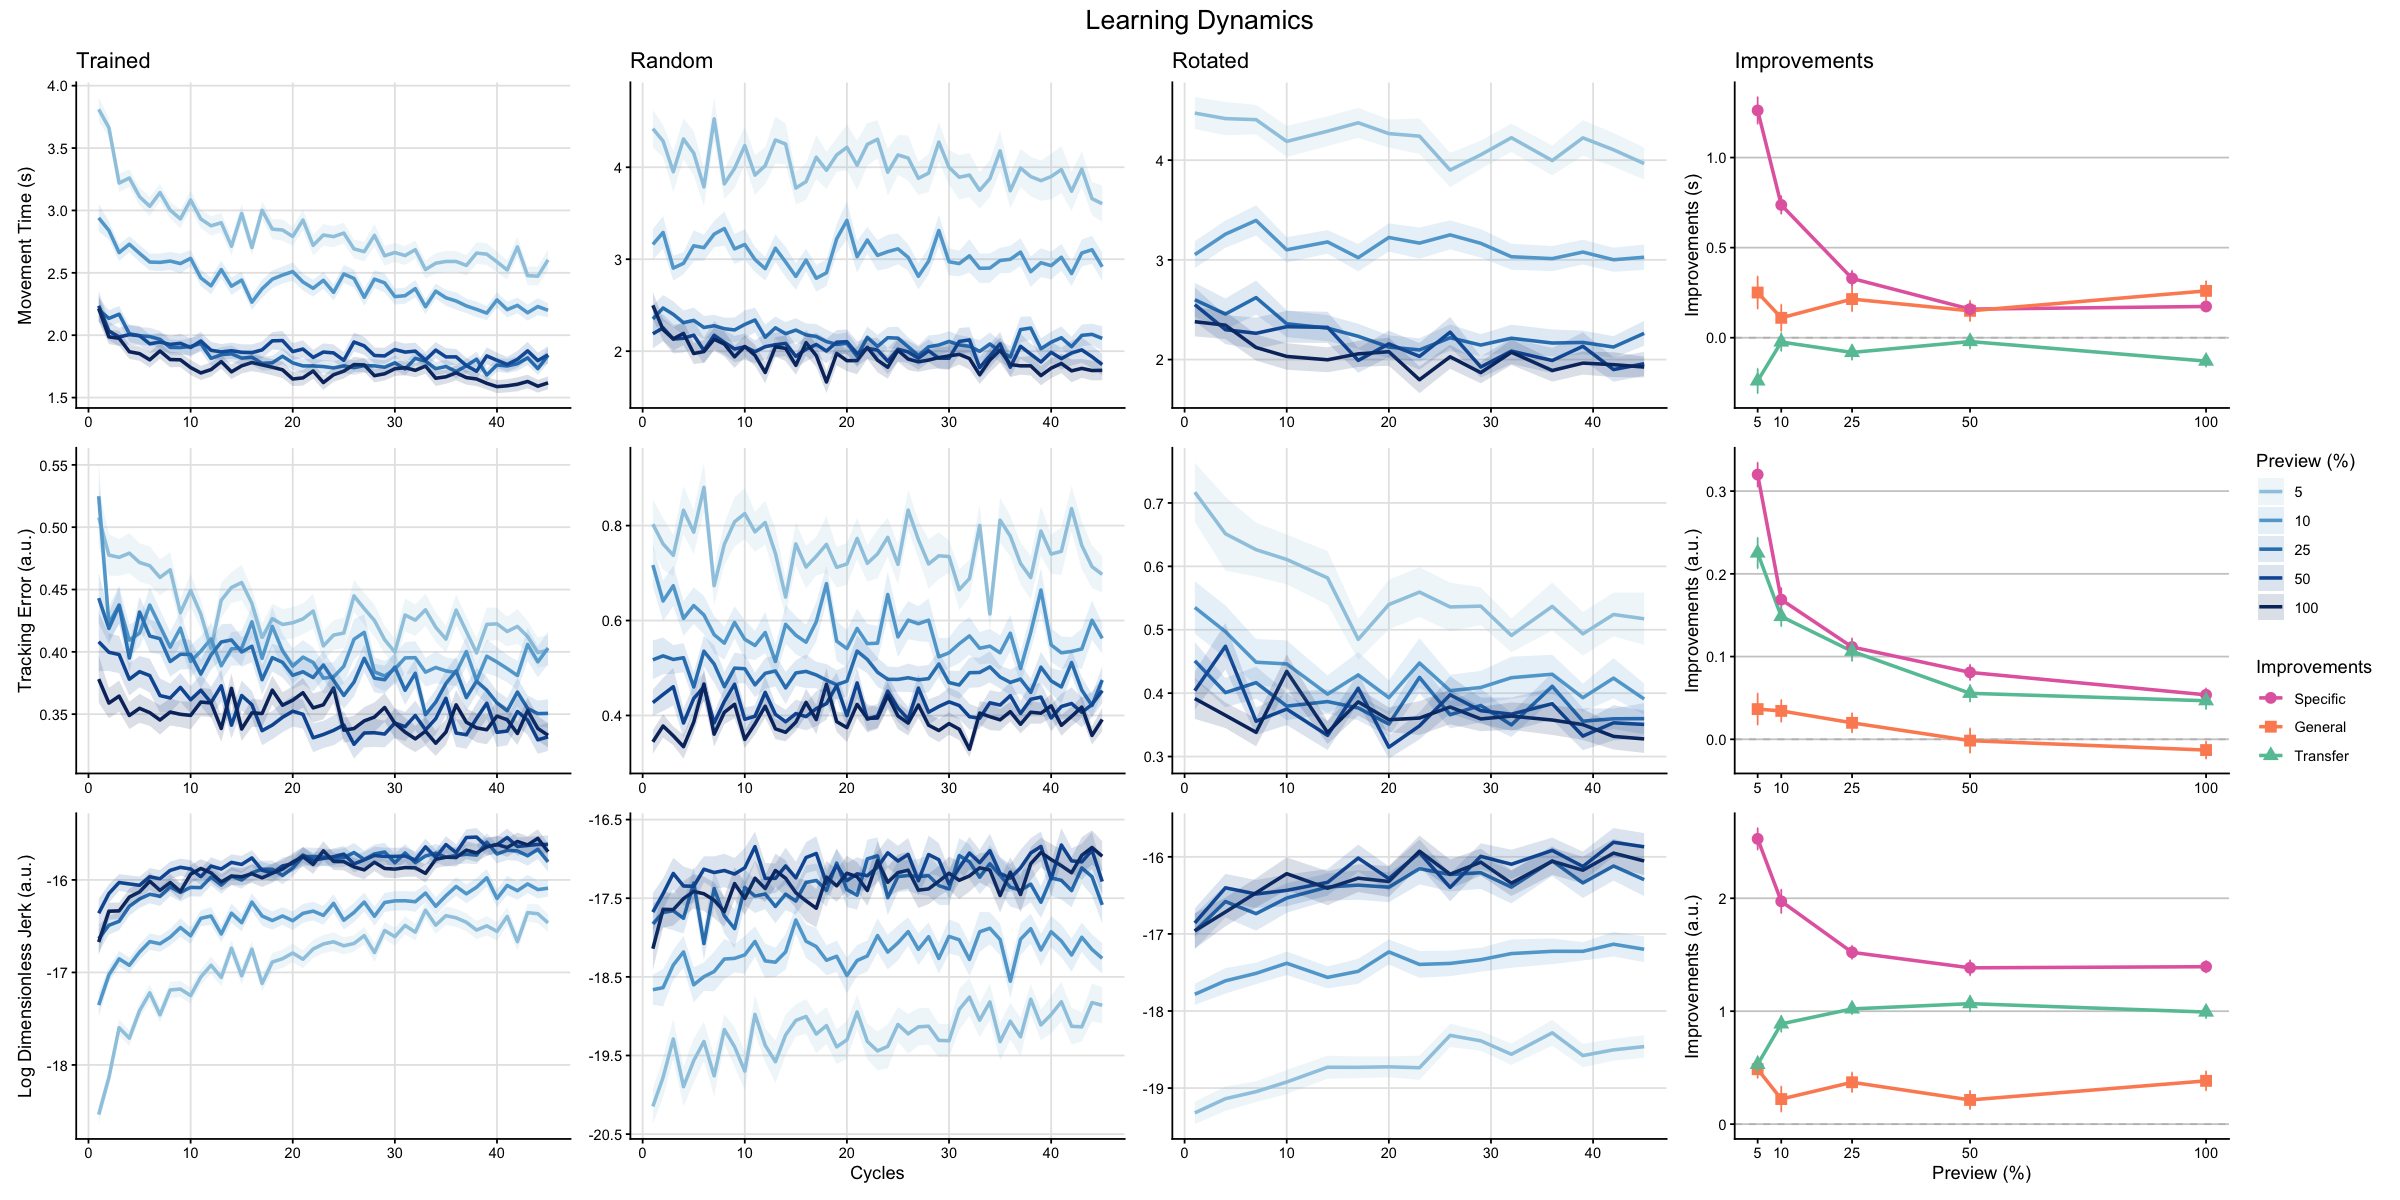

In [95]:
# Pivot long for easier ggplot mapping
df_long <- df %>%
  pivot_longer(cols = c("MT", "ERROR", "LDJ"), 
               names_to = "metric", values_to = "value") %>%
  drop_na(value)

# 1. Summarize Data for the Learning Curves (Columns 1-3)
df_curves <- df_long %>%
  group_by(metric, condition, traj_type, block) %>%
  summarize(
    mean_val = mean(value, na.rm = TRUE),
    sem_val = sd(value, na.rm = TRUE) / sqrt(n()),
    .groups = "drop"
  ) %>%
  mutate(condition = factor(condition, levels = conditions))

# 2. Summarize Data for the Improvements/Effects (Column 4)
df_subj_summary <- df_long %>%
  filter((traj_type == "random" & stage %in% c("EARLY", "LATE")) |
         (traj_type == "learned" & stage == "LATE") |
         (traj_type == "rotated" & stage == "LATE")) %>%
  group_by(subject_id, condition, traj_type, stage, metric) %>%
  summarize(subj_mean = mean(value, na.rm = TRUE), .groups = "drop")

df_subj_wide <- df_subj_summary %>%
  mutate(key = paste(traj_type, stage, sep = "_")) %>%
  select(-traj_type, -stage) %>%
  pivot_wider(names_from = key, values_from = subj_mean)

df_effects_subj <- df_subj_wide %>%
  mutate(
    dir = metric_direction[metric],
    Specific = dir * (random_LATE - learned_LATE),
    General  = dir * (random_EARLY - random_LATE),
    Transfer = dir * (random_LATE - rotated_LATE)
  ) %>%
  select(subject_id, condition, metric, Specific, General, Transfer) %>%
  pivot_longer(cols = c(Specific, General, Transfer), 
               names_to = "effect_type", values_to = "effect_val")

df_effects <- df_effects_subj %>%
  group_by(condition, metric, effect_type) %>%
  summarize(
    mean_effect = mean(effect_val, na.rm = TRUE),
    sem_effect = sd(effect_val, na.rm = TRUE) / sqrt(n()),
    .groups = "drop"
  ) %>%
  mutate(effect_type = factor(effect_type, levels = c("Specific", "General", "Transfer")))


# STYLING & COLORS
preview_colors <- colorRampPalette(brewer.pal(9, "Blues")[4:9])(length(conditions))

effect_colors <- c("Specific" = "#e46aaf", "General" = "#fc8d62", "Transfer" = "#66c2a5")
effect_shapes <- c("Specific" = 16, "General" = 15, "Transfer" = 17) 


# BUILD THE PLOTS
plot_list <- list()

for (r in seq_along(metrics)) {
  m <- metrics[r]
  
  # --- 1. LEARNING CURVES (Cols 1-3) ---
  for (c in seq_along(traj_types)) {
    t <- traj_types[c]
    
    p <- ggplot(df_curves %>% filter(metric == m, traj_type == t),
                aes(x = block, y = mean_val, color = condition, fill = condition)) +
      geom_line(linewidth = 1) +
      geom_ribbon(aes(ymin = mean_val - sem_val, ymax = mean_val + sem_val), alpha = 0.15, color = NA) +
      scale_color_manual(values = preview_colors, name = "Preview (%)") +
      scale_fill_manual(values = preview_colors, name = "Preview (%)") +
      theme_classic() +
      theme(panel.grid.major = element_line(color = "grey90", alpha=0.5))
    
    if (c == 1) p <- p + ylab(ylabels[m]) else p <- p + ylab(NULL)
    if (r == 1) p <- p + ggtitle(str_to_title(str_replace(t, "learned", "trained")))
    if (r == 3 && c == 2) p <- p + xlab("Cycles") else p <- p + xlab(NULL)
    
    plot_list <- append(plot_list, list(p))
  }
  
  # IMPROVEMENTS / EFFECTS
  p_eff <- ggplot(df_effects %>% filter(metric == m),
                  aes(x = condition, y = mean_effect, color = effect_type, shape = effect_type)) +
    geom_hline(yintercept = 0, linetype = "dashed", color = "gray") +
    geom_line(linewidth = 1, aes(group = effect_type)) +  # FIX: strictly map group to the local column
    geom_point(size = 3) +
    geom_errorbar(aes(ymin = mean_effect - sem_effect, ymax = mean_effect + sem_effect), width = 0.2) +
    scale_color_manual(values = effect_colors, name = "Improvements") +
    scale_shape_manual(values = effect_shapes, name = "Improvements") +
    scale_x_continuous(breaks = conditions) +
    theme_classic() +
    theme(panel.grid.major.y = element_line(color = "grey80", alpha=0.5))
  
  if (r == 1) {
    p_eff <- p_eff + ggtitle("Improvements") + ylab("Improvements (s)")
  } else {
    p_eff <- p_eff + ylab("Improvements (a.u.)")
  }
  if (r == 3) {
    p_eff <- p_eff + xlab("Preview (%)")
  } else {
    p_eff <- p_eff + xlab(NULL)
  }
  
  plot_list <- append(plot_list, list(p_eff))
}

final_plot <- wrap_plots(plot_list, ncol = 4) + 
  plot_layout(guides = 'collect') + 
  plot_annotation(
    title = 'Learning Dynamics',
    theme = theme(plot.title = element_text(size = 16, hjust = 0.5))
  )

# Display the plot inline
print(final_plot)

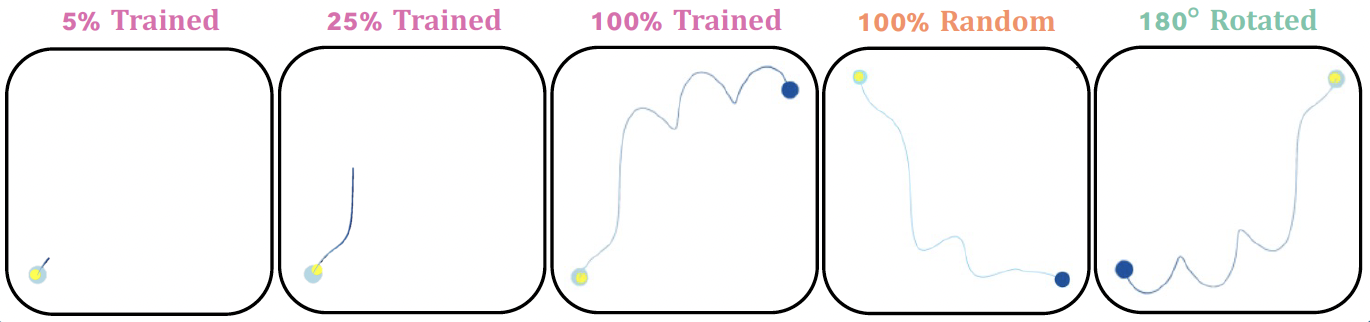

### H1: Trajectory-specific gains reflect improved anticipation of upcoming movements

To qualify trajectory-specific learning, we compared late performance on trained versus random trajectories. With learning, movement time were substantially faster ($F(1, 281) = 593.6, \; p<.001$), error was markedly lower ($F(1, 281) = 797.5, \; p < .001$), movement was significantly smoother ($F(1, 281) = 2494.8, \; p<.001$) for trained trajectories.

In [96]:
# Aggregate to get one mean score per subject per cell
df_stats <- df %>%
  # Group by the factors needed for the ANOVAs
  group_by(subject_id, condition, traj_type, stage) %>%
  summarize(
    MT = mean(MT, na.rm = TRUE),
    ERROR = mean(ERROR, na.rm = TRUE),
    LDJ = mean(LDJ, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  # Convert factors for rstatix
  mutate(
    subject_id = as_factor(subject_id),
    condition = as_factor(condition),
    traj_type = as_factor(traj_type),
    stage = factor(stage, levels = c("EARLY", "LATE"))
  )

# Define the dependent variables to loop through
dvs <- c("MT", "ERROR", "LDJ")

In [97]:
cat("RESEARCH QUESTION 1: CONTINUOUS MOTOR SKILL IMPROVEMENTS")

# HYPOTHESIS 1: Trajectory-specific prediction (Mixed ANOVA)
# Filter: LATE stage only, comparing learned vs random
df_h1a <- df_stats %>%
  filter(stage == "LATE", traj_type %in% c("learned", "random")) %>%
  mutate(traj_type = droplevels(traj_type))

cat("\n--- Hypothesis 1: LATE Stage (Learned vs Random) ---\n")

for (dv in dvs) {
  cat(paste0("\n>>> Dependent Variable: ", dv, " <<<\n"))
  
  # Run 2-Way Mixed ANOVA
  res_aov_1a <- anova_test(
    data = df_h1a,
    dv = !!sym(dv),
    wid = subject_id,
    between = condition,
    within = traj_type
  )
  
  print(get_anova_table(res_aov_1a))
}

RESEARCH QUESTION 1: CONTINUOUS MOTOR SKILL IMPROVEMENTS
--- Hypothesis 1: LATE Stage (Learned vs Random) ---

>>> Dependent Variable: MT <<<
ANOVA Table (type III tests)

               Effect DFn DFd       F        p p<.05   ges
1           condition   4 281  33.239 1.06e-22     * 0.311
2           traj_type   1 281 593.553 3.04e-71     * 0.088
3 condition:traj_type   4 281  93.955 1.27e-50     * 0.058

>>> Dependent Variable: ERROR <<<
ANOVA Table (type III tests)

               Effect DFn DFd       F        p p<.05   ges
1           condition   4 281  29.338 2.15e-20     * 0.270
2           traj_type   1 281 797.541 4.70e-84     * 0.247
3 condition:traj_type   4 281  84.494 5.05e-47     * 0.122

>>> Dependent Variable: LDJ <<<
ANOVA Table (type III tests)

               Effect DFn DFd        F         p p<.05   ges
1           condition   4 281   14.211  1.41e-10     * 0.160
2           traj_type   1 281 2494.802 8.86e-142     * 0.345
3 condition:traj_type   4 281   39.434  3.35e

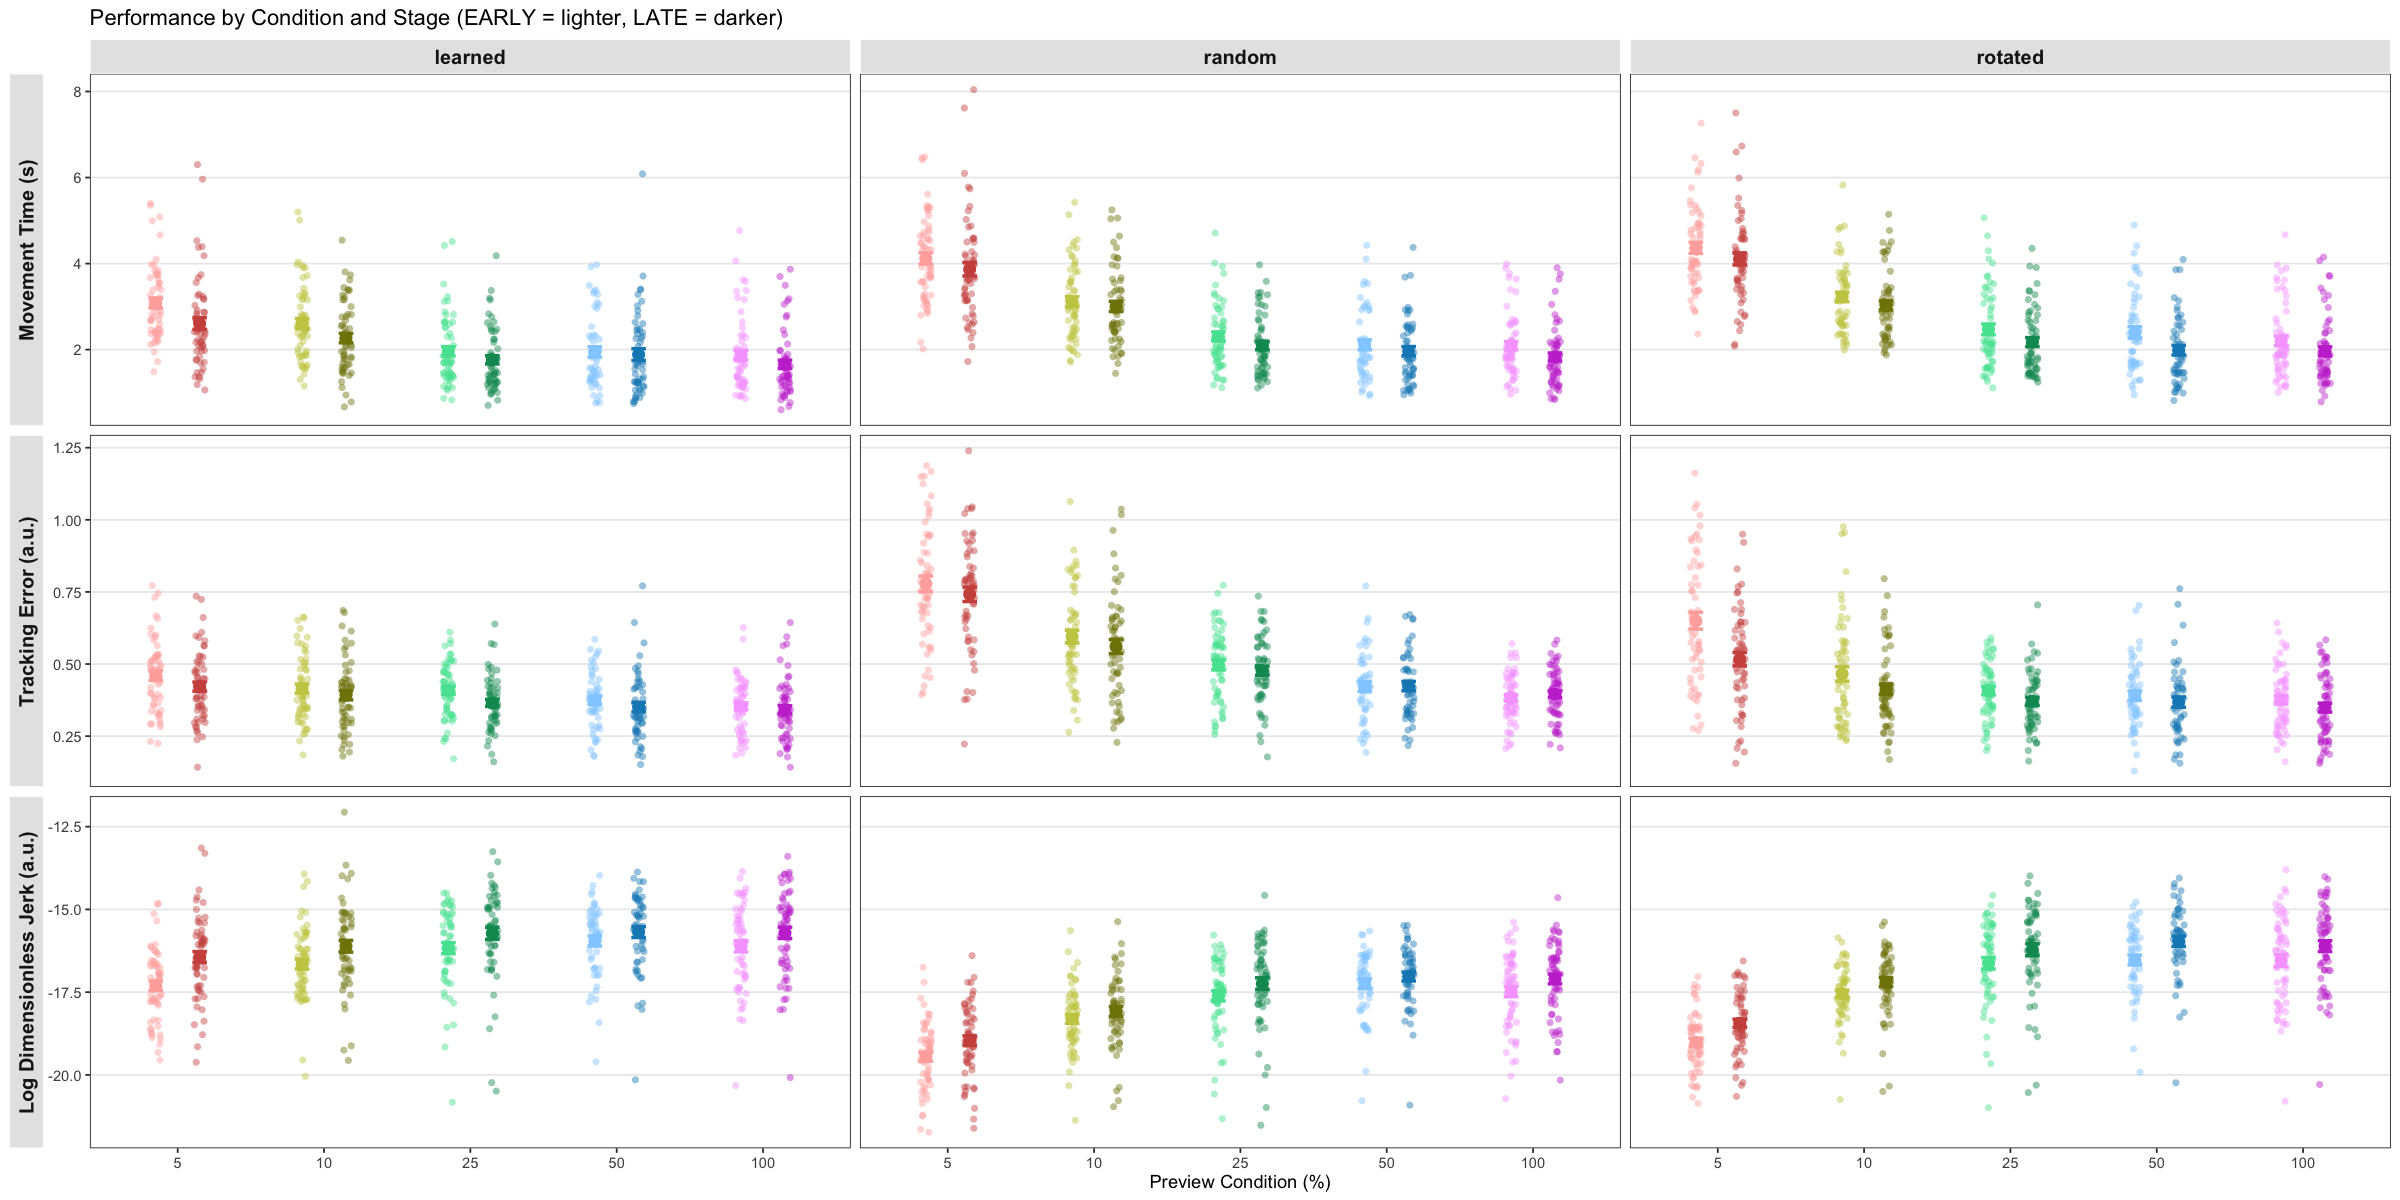

In [98]:
# 1. Group by subject_id, condition, traj_type, stage and get mean
df_stage_subj <- df %>%
  group_by(subject_id, condition, traj_type, stage) %>%
  summarize(across(all_of(metrics), \(x) mean(x, na.rm = TRUE)), .groups = "drop") %>%
  drop_na(stage, condition) %>%
  filter(traj_type %in% traj_desired)

# 2. Factor ordering
df_stage_subj$stage <- factor(df_stage_subj$stage, levels = c("EARLY", "LATE"))
num_conditions <- sort(as.numeric(unique(as.character(df_stage_subj$condition))))
df_stage_subj$condition <- factor(df_stage_subj$condition, levels = as.character(num_conditions))
df_stage_subj$traj_type <- factor(df_stage_subj$traj_type, 
                                  levels = traj_desired[traj_desired %in% unique(df_stage_subj$traj_type)])

# 3. Create combined factor for mapping exact shaded colors
df_stage_subj <- df_stage_subj %>%
  mutate(cond_stage = paste(condition, stage, sep = "_"))

# 4. Convert to LONG format so all metrics can be plotted in one figure
df_plot_long <- df_stage_subj %>%
  pivot_longer(cols = any_of(metrics), names_to = "metric", values_to = "value") %>%
  drop_na(value)

# 5. Map the metrics to their descriptive Y-axis labels for the plot
df_plot_long <- df_plot_long %>%
  mutate(metric_label = factor(ylabels[metric], levels = ylabels))


# COLOR PALETTE GENERATION (Lighter EARLY, Darker LATE)
cond_order <- levels(df_stage_subj$condition)
base_colors <- scales::hue_pal()(length(cond_order)) 

custom_colors <- c()
for (i in seq_along(cond_order)) {
  c <- cond_order[i]
  b_col <- base_colors[i]
  custom_colors[paste(c, "EARLY", sep = "_")] <- colorspace::lighten(b_col, amount = 0.4)
  custom_colors[paste(c, "LATE", sep = "_")]  <- colorspace::darken(b_col, amount = 0.2)
}

# plotting
unified_plot <- ggplot(df_plot_long, aes(x = condition, y = value, 
                                         color = cond_stage, group = stage)) +
  
  # Scatter points with jitter and dodge
  geom_point(position = position_jitterdodge(jitter.width = 0.15, dodge.width = 0.6),
             alpha = 0.45, size = 2, stroke = 0) +
  
  # Mean +/- SEM error bars
  stat_summary(fun.data = mean_se, geom = "errorbar", 
               position = position_dodge(width = 0.6), 
               width = 0.2, linewidth = 1) +
  
  # Mean dot
  stat_summary(fun = mean, geom = "point", 
               position = position_dodge(width = 0.6), 
               size = 3) +
  
  # facet_grid: Rows = metrics, Columns = trajectories
  # scales = "free_y" lets MT, ERROR, and LDJ have their own y-axis ranges
  # switch = "y" moves the row labels to the left side
  facet_grid(metric_label ~ traj_type, scales = "free_y", switch = "y") +
  
  # Apply custom colors
  scale_color_manual(values = custom_colors) +
  
  # Styling and Labels
  labs(
    title = "Performance by Condition and Stage (EARLY = lighter, LATE = darker)",
    x = "Preview Condition (%)",
    y = NULL # Set to NULL because the facet strips act as the Y labels
  ) +
  theme_bw() +
  theme(
    strip.background = element_rect(fill = "grey90", color = "white"),
    strip.text = element_text(size = 12, face = "bold"),
    strip.placement = "outside",         # Puts the Y-axis facet labels OUTSIDE the axis text
    panel.grid.major.x = element_blank(),
    panel.grid.minor = element_blank(),
    legend.position = "none"             # Hide legend to match your preference
  )

# Display the plot
print(unified_plot)

### Sub-Hypothesis 1a: Cross-correlation showed participants learned to predict upcoming movements with practice

To answer this, we analyzed performance in the error domain by comparing early and late stages of the experiment.

We then zoomed in on the turning points to understand how behavior changed. The x-axis represents position along the trajectory, and the y-axis shows normalized turning-point density—how often participants executed turns over time. Because the 100% preview late stage reflects near-optimal performance, we used it as a baseline.

In the 5% preview condition, early-stage behavior (purple) shows that participants initially overshoot and then lag behind at each turning point. After practice (green), the peaks shift leftward, indicating reduced lag. In other words, participants began initiating turns earlier, suggesting they were anticipating upcoming trajectory changes.

As the preview increased, these density peaks not only shifted left but also increased in magnitude, approaching the baseline. This indicates that behavior became both faster and more precise with greater visibility and learning.

To quantify this effect, we computed the cross-correlation between participants’ turning behavior and the baseline. Peak correlation increased both with higher preview and with practice, indicating improved alignment with the target trajectory.

We also examined the lag at peak correlation. In the early stage, lags were consistently positive, reflecting delayed responses. With practice, these lags decreased or disappeared, indicating a shift from reactive to anticipatory control.

In summary, these results suggest that participants learned trajectory-specific structure, enabling them to better predict upcoming movements. Crucially, this learning and the resulting anticipation were strongest under limited preview conditions.

In [99]:
## Helper Functions for Trajectory Analysis

# 1. RESAMPLE TRAJECTORY (Spatial Interpolation)
# Resamples a 2D trajectory so it has exactly `n_points` evenly 
# spaced along its cumulative arc-length.
resample_traj <- function(x, y, n_points = 200) {
  
  # Calculate step-by-step distances between points
  dx <- diff(x)
  dy <- diff(y)
  
  # Cumulative distance (arc-length) from start to finish
  dist <- c(0, cumsum(sqrt(dx^2 + dy^2)))
  total_dist <- tail(dist, 1)
  
  # Create a new, evenly spaced distance vector
  target_dist <- seq(0, total_dist, length.out = n_points)
  
  # Interpolate x and y coordinates at the new evenly spaced distances
  # We use ties = "ordered" to handle instances where points might overlap
  x_resampled <- approx(x = dist, y = x, xout = target_dist, ties = "ordered")$y
  y_resampled <- approx(x = dist, y = y, xout = target_dist, ties = "ordered")$y
  
  return(list(x = x_resampled, y = y_resampled))
}


# 2. FIND TURNING POINTS (Curvature Peaks)
# Identifies the indices of sharp bends by calculating the 2D spatial 
# curvature (kappa) and finding its local maxima.
find_turning_points <- function(x, y, smoothing_k = 5, peak_threshold_sd = 1) {
  
  # 1st derivatives (Velocity / Direction)
  dx <- c(0, diff(x))
  dy <- c(0, diff(y))
  
  # 2nd derivatives (Acceleration / Change in Direction)
  ddx <- c(0, diff(dx))
  ddy <- c(0, diff(dy))
  
  # Calculate Curvature (kappa)
  # Formula: |x'*y'' - y'*x''| / (x'^2 + y'^2)^(3/2)
  denom <- (dx^2 + dy^2)^(1.5) + 1e-8 # add 1e-8 to prevent division by zero
  kappa <- abs(dx * ddy - dy * ddx) / denom
  
  # Smooth the curvature to prevent microscopic noise from registering as peaks
  # (Requires the 'zoo' package, which was included in the main script)
  kappa_smooth <- zoo::rollmean(kappa, k = smoothing_k, fill = NA, align = "center")
  
  # Find Local Maxima (points higher than the point before and after them)
  is_peak <- kappa_smooth > dplyr::lag(kappa_smooth) & 
             kappa_smooth > dplyr::lead(kappa_smooth)
  
  # Define a threshold to ignore flat wiggles and only grab actual sharp turns
  # Default: Must be 1 standard deviation above the mean curvature
  threshold <- mean(kappa_smooth, na.rm = TRUE) + (peak_threshold_sd * sd(kappa_smooth, na.rm = TRUE))
  
  # Get the indices where it is both a peak and above the threshold
  peaks <- which(is_peak & kappa_smooth > threshold)
  
  return(peaks)
}

In [100]:
N <- 200
N_BINS <- 200
MAX_LAG <- 50


# 1. Custom Linear Cross-Correlation
linear_xcorr <- function(a, b, max_lag = 50) {
  a <- (a - mean(a, na.rm = TRUE)) / (sd(a, na.rm = TRUE) + 1e-8)
  b <- (b - mean(b, na.rm = TRUE)) / (sd(b, na.rm = TRUE) + 1e-8)
  n <- length(a)
  lags <- seq(-max_lag, max_lag)
  corrs <- numeric(length(lags))
  
  for (i in seq_along(lags)) {
    lag <- lags[i]
    if (lag < 0) {
      shifted_a <- c(tail(a, n + lag), rep(NA, -lag))
      ref_b <- b
    } else if (lag > 0) {
      shifted_a <- c(rep(NA, lag), head(a, n - lag))
      ref_b <- b
    } else {
      shifted_a <- a
      ref_b <- b
    }
    
    valid <- !is.na(shifted_a) & !is.na(ref_b)
    corrs[i] <- mean(shifted_a[valid] * ref_b[valid])
  }
  
  return(list(lags = lags / n, corrs = corrs))
}

# 2. Gaussian Smoothing 1D
gaussian_filter1d <- function(x, sigma = 2) {
  radius <- ceiling(4 * sigma)
  x_seq <- seq(-radius, radius)
  weights <- dnorm(x_seq, sd = sigma)
  weights <- weights / sum(weights)
  
  # Convolve
  smoothed <- stats::filter(x, weights, sides = 2)
  # Fill NA edges
  smoothed <- zoo::na.fill(smoothed, "extend")
  return(as.numeric(smoothed))
}


# DATA CLEANING & TARGET REFERENCE
df_use <- df %>%
  filter(!is.na(condition), !is.na(subject_id), !is.na(stage), 
         !is.na(cursor_x), !is.na(cursor_y), 
         !is.na(target_x), !is.na(target_y)) %>%
  filter(as.character(traj_type) == "learned") %>%
  arrange(subject_id, trial_index)

conditions <- sort(as.numeric(unique(df_use$condition)))
stage_order <- unique(as.character(df_use$stage))
stages_to_plot <- stage_order[1:2]
stage_colors <- c("EARLY" = "#800080", "LATE" = "#008000")
names(stage_colors) <- stages_to_plot # Ensure names match exactly

# Get Target Trajectory & TP Positions
r0 <- df_use[1, ]
tx0 <- as.numeric(fromJSON(r0$target_x))
ty0 <- as.numeric(fromJSON(r0$target_y))

target_resampled <- resample_traj(tx0, ty0, n_points = N)
txr <- target_resampled$x # Adjust based on your function's return structure
tyr <- target_resampled$y

target_tp_idx <- find_turning_points(txr, tyr)

# Calculate Target Arc-Length
dx <- diff(txr)
dy <- diff(tyr)
arc <- c(0, cumsum(sqrt(dx^2 + dy^2)))
arc <- arc / tail(arc, 1)
target_tp_pos <- arc[target_tp_idx]

# MAIN PROCESSING LOOP (Density per subject)
densities_list <- list()

# Group data
grouped_df <- df_use %>%
  filter(stage %in% stages_to_plot) %>%
  group_by(condition, subject_id, stage) %>%
  group_split()


for (grp in grouped_df) {
  cond <- as.character(grp$condition[1])
  sid <- as.character(grp$subject_id[1])
  st <- as.character(grp$stage[1])
  
  cxs <- list(); cys <- list()
  
  for (i in 1:nrow(grp)) {
    tryCatch({
      cx <- as.numeric(fromJSON(grp$cursor_x[i]))
      cy <- as.numeric(fromJSON(grp$cursor_y[i]))
      resampled <- resample_traj(cx, cy, n_points = N)
      cxs[[i]] <- resampled$x
      cys[[i]] <- resampled$y
    }, error = function(e) NULL)
  }
  
  if (length(cxs) == 0) next
  
  # Subject Mean Trajectory
  cx_mat <- do.call(rbind, cxs)
  cy_mat <- do.call(rbind, cys)
  cxm <- colMeans(cx_mat, na.rm = TRUE)
  cym <- colMeans(cy_mat, na.rm = TRUE)
  
  tp_idx <- find_turning_points(cxm, cym)
  if (length(tp_idx) == 0) next
  
  # Normalized Arc-length
  dist_diff <- sqrt(diff(cxm)^2 + diff(cym)^2)
  dist_arc <- c(0, cumsum(dist_diff))
  dist_arc <- dist_arc / (tail(dist_arc, 1) + 1e-8)
  
  # Density Distribution
  breaks <- seq(0, 1, length.out = N_BINS + 1)
  hist_res <- hist(dist_arc[tp_idx], breaks = breaks, plot = FALSE)
  dens <- hist_res$counts / (length(tp_idx) + 1e-8)
  dens_smooth <- gaussian_filter1d(dens, sigma = 2)
  
  bins_x <- hist_res$mids # Center of bins
  
  # Save to list
  densities_list[[length(densities_list) + 1]] <- tibble(
    condition = as.numeric(cond),
    subject_id = sid,
    stage = st,
    bin_x = bins_x,
    density = dens_smooth
  )
}

df_density_all <- bind_rows(densities_list)

# DEFINE BASELINES (Highest condition is reference)
baseline_cond <- max(conditions)
baseline_stage <- stages_to_plot[2] # Typically "LATE"

df_baseline <- df_density_all %>%
  filter(condition == baseline_cond, stage == baseline_stage)

# Global baseline
baseline_global <- df_baseline %>%
  group_by(bin_x) %>%
  summarize(mean_density = mean(density, na.rm = TRUE), .groups = "drop") %>%
  pull(mean_density)

# Subject baselines
baseline_subject_list <- split(df_baseline$density, df_baseline$subject_id)

# FIGURE 1: DENSITY PLOT WITH SEM
df_density_summary <- df_density_all %>%
  group_by(condition, stage, bin_x) %>%
  summarize(
    mean_dens = mean(density, na.rm = TRUE),
    sem_dens = sd(density, na.rm = TRUE) / sqrt(n()),
    .groups = "drop"
  )

# Add dummy global baseline data for plotting
df_bg <- expand_grid(condition = conditions, bin_x = unique(df_density_all$bin_x)) %>%
  mutate(bg_density = rep(baseline_global, length(conditions)))

fig_dens <- ggplot() +
  # Baseline line
  geom_line(data = df_bg, aes(x = bin_x, y = bg_density), color = "gray", linewidth = 1, alpha = 0.5) +
  # Target TP vertical lines
  geom_vline(xintercept = target_tp_pos, color = "gray", linetype = "dashed", alpha = 0.4) +
  # SEM Ribbon
  geom_ribbon(data = df_density_summary, 
              aes(x = bin_x, ymin = mean_dens - sem_dens, ymax = mean_dens + sem_dens, fill = stage),
              alpha = 0.2) +
  # Mean Line
  geom_line(data = df_density_summary, aes(x = bin_x, y = mean_dens, color = stage), linewidth = 1) +
  scale_color_manual(values = stage_colors) +
  scale_fill_manual(values = stage_colors) +
  facet_wrap(~ condition, nrow = 1, labeller = as_labeller(function(x) paste0(x, "%"))) +
  labs(
    title = "Turning Point Density",
    x = "Normalized trajectory position (arc-length)",
    y = "Turning point density",
    color = "Stage", fill = "Stage"
  ) +
  theme_bw() +
  theme(strip.background = element_rect(fill = "white"), 
        panel.grid.minor = element_blank())

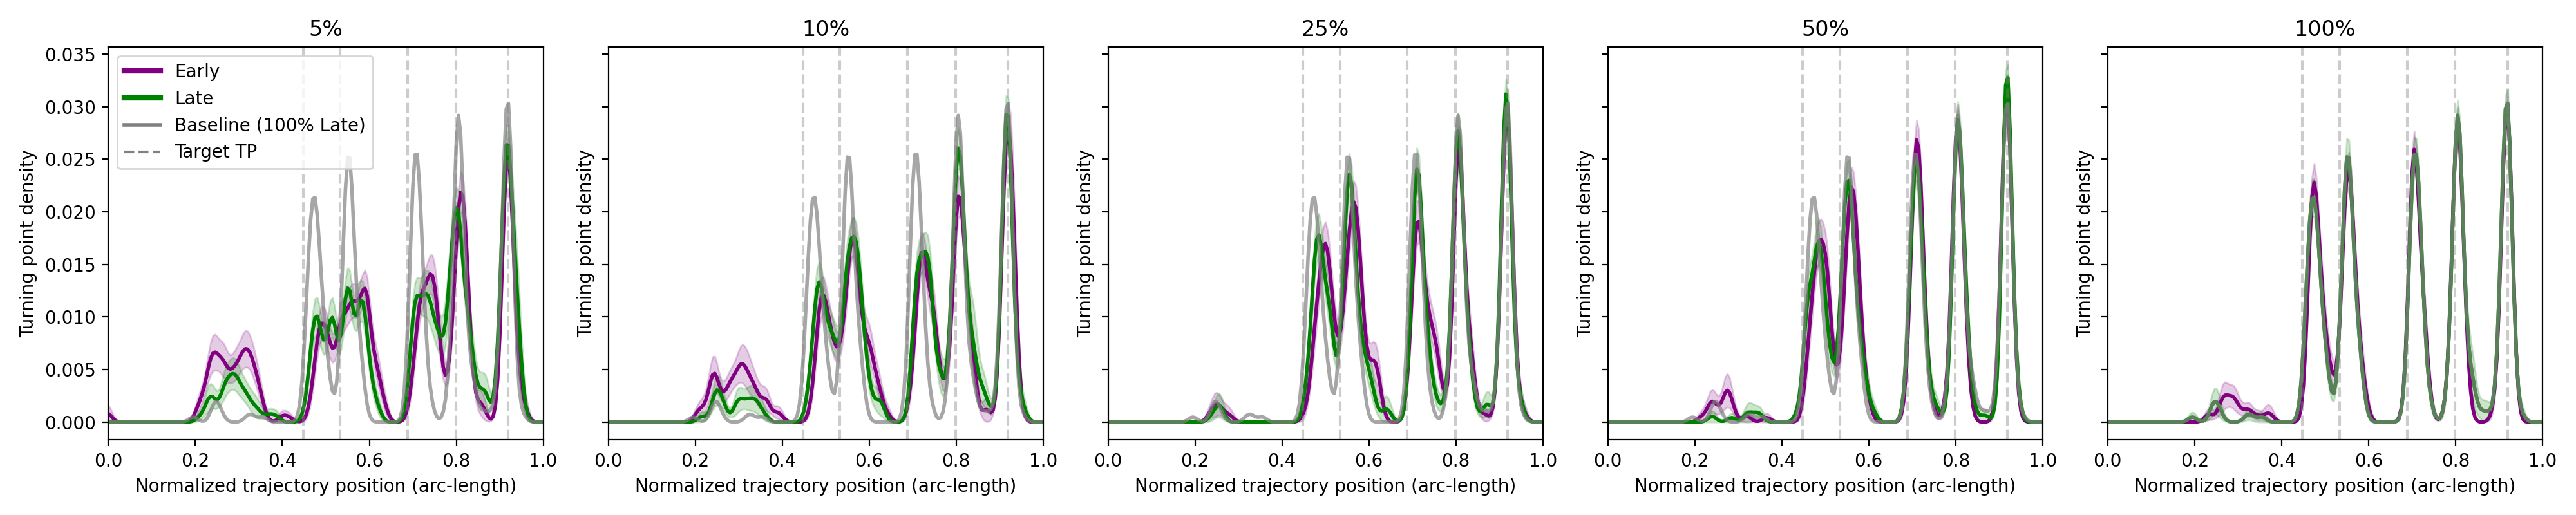

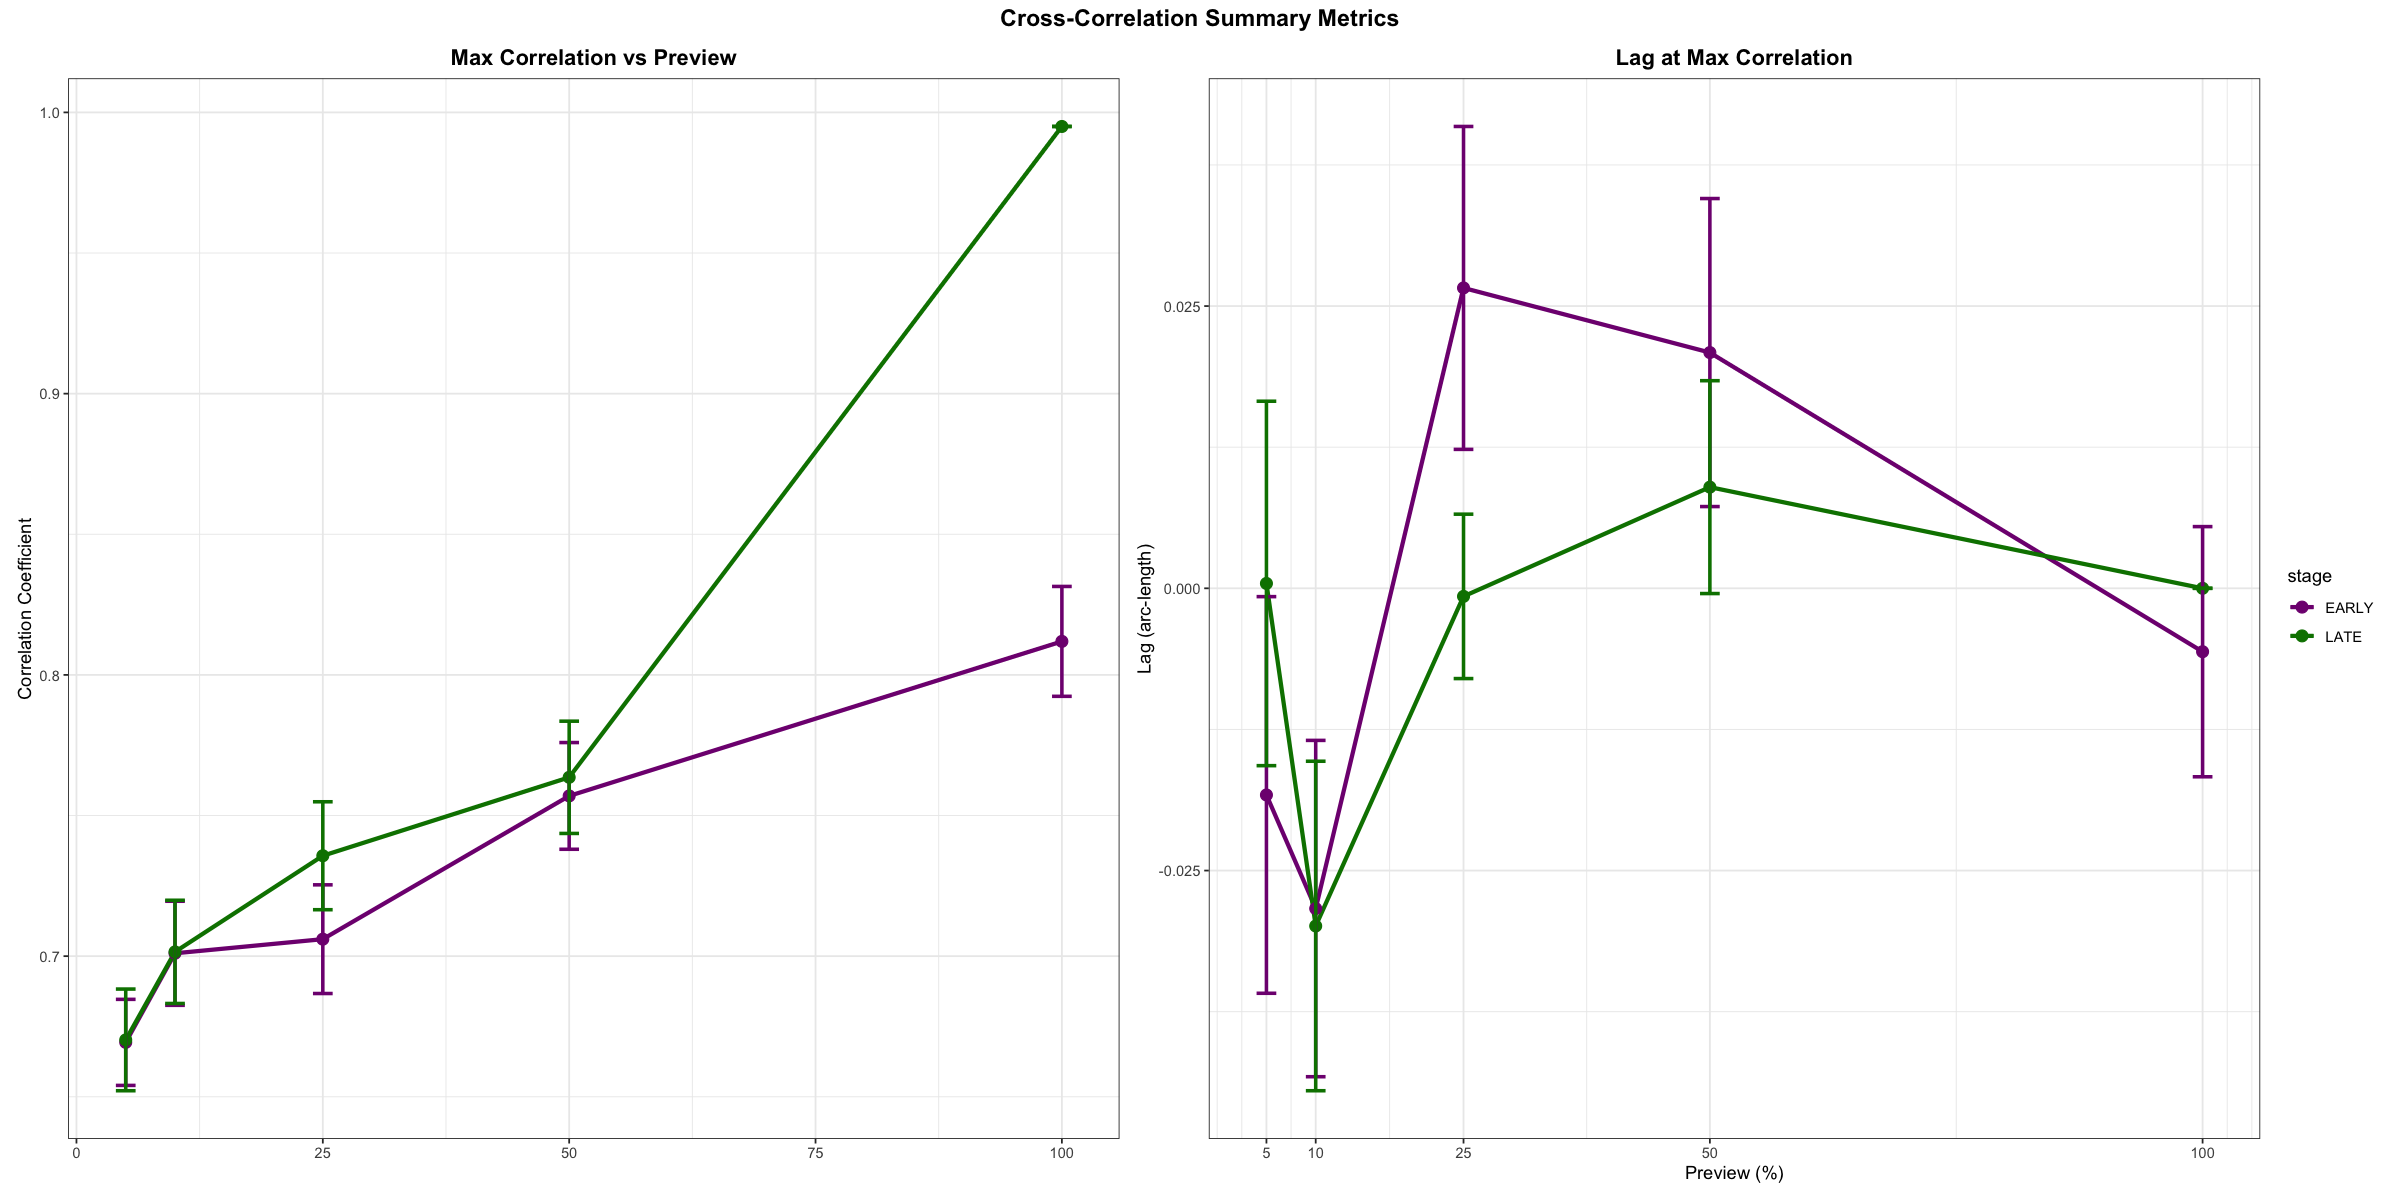

In [101]:
# FIGURE 2: CROSS-CORRELATION & LAG SUMMARY METRICS
xcorr_results <- list()

# Re-group by Condition, Subject, Stage for Correlation
unique_combos <- df_density_all %>% distinct(condition, subject_id, stage)

for (i in 1:nrow(unique_combos)) {
  c <- unique_combos$condition[i]
  sid <- unique_combos$subject_id[i]
  st <- unique_combos$stage[i]
  
  sig <- df_density_all %>% filter(condition == c, subject_id == sid, stage == st) %>% pull(density)
  
  # Get Subject's Baseline, fallback to global
  ref <- if (!is.null(baseline_subject_list[[sid]])) baseline_subject_list[[sid]] else baseline_global
  
  xc <- linear_xcorr(sig, ref, max_lag = MAX_LAG)
  
  best_idx <- which.max(xc$corrs)
  
  xcorr_results[[i]] <- tibble(
    condition = c,
    subject_id = sid,
    stage = st,
    max_corr = xc$corrs[best_idx],
    best_lag = xc$lags[best_idx]
  )
}

df_xcorr <- bind_rows(xcorr_results)

# Summary for plotting
df_xcorr_summary <- df_xcorr %>%
  group_by(condition, stage) %>%
  summarize(
    mean_corr = mean(max_corr, na.rm = TRUE),
    sem_corr = sd(max_corr, na.rm = TRUE) / sqrt(n()),
    mean_lag = mean(best_lag, na.rm = TRUE),
    sem_lag = sd(best_lag, na.rm = TRUE) / sqrt(n()),
    .groups = "drop"
  ) %>%
  mutate(stage = factor(stage, levels = stages_to_plot))

# Plot Correlation
p_corr <- ggplot(df_xcorr_summary, aes(x = condition, y = mean_corr, color = stage, group = stage)) +
  geom_line(linewidth = 1.2) +
  geom_point(size = 3) +
  geom_errorbar(aes(ymin = mean_corr - sem_corr, ymax = mean_corr + sem_corr), width = 2, linewidth = 1) +
  scale_color_manual(values = stage_colors) +
  labs(title = "Max Correlation vs Preview", y = "Correlation Coefficient", x = "") +
  theme_bw() +
  theme(legend.position = "none", plot.title = element_text(hjust = 0.5, face = "bold"))

# Plot Lag
p_lag <- ggplot(df_xcorr_summary, aes(x = condition, y = mean_lag, color = stage, group = stage)) +
  geom_line(linewidth = 1.2) +
  geom_point(size = 3) +
  geom_errorbar(aes(ymin = mean_lag - sem_lag, ymax = mean_lag + sem_lag), width = 2, linewidth = 1) +
  scale_color_manual(values = stage_colors) +
  scale_x_continuous(breaks = conditions) +
  labs(title = "Lag at Max Correlation", y = "Lag (arc-length)", x = "Preview (%)") +
  theme_bw() +
  theme(plot.title = element_text(hjust = 0.5, face = "bold"))

# Combine with Patchwork
fig_xcorr <- (p_corr | p_lag) + 
  plot_layout(guides = 'collect') + 
  plot_annotation(title = "Cross-Correlation Summary Metrics",
                  theme = theme(plot.title = element_text(size = 14, hjust = 0.5, face = "bold")))

print(fig_xcorr)

### H1: General skill improvements reflect increased continuous motor efficiency rather than expanded planning capacity

We analyzed baseline motor performance in trials with minimal learning (early random trials). We founded limited preview led to markedly slower movement time ($F(4, 281) = 64.7, \; p < .001$), larger errors ($F(4, 281) = 68.2, \; p < .001$), higher jerks ($F(4, 281) = 38.2, \; p < .001$) whereas longer preview yielded better performance. 

We then asked whether general movement improved with practice. We compared early and late performance on random trajectories. With practice, participants move faster ($F(1, 281) = 39.4, \; p<.001$), reduced error ($F(1, 281) = 5.8, \; p < .001$), and smoother movements ($F(1, 281) = 69.9, \; p < .001$) across all preview conditions.

### Sub-Hypothesis 1b: Bootstrapping showed there is no expansion of planning capacity

We next quantified the "planning horizon", the preview level beyond which additional trajectory information yielded minimal benefit by fitting an exponential function and identifying its asymptote. Planning horizon at this baseline stage was $22.6\% \; (95\%~\mathrm{CI}: 14.87\text{--}33.9$), indicating the motor performance is constrained by a limited planning window.

Surprisingly, the planning horizon did not extend with learning $(95\%~\mathrm{CI}: 17.4\text{--}39.8$; Early-Late = $4.6\%, \; 95\%~\mathrm{CI}: -0.7\text{--}12.0$). Thus, general skill improvements reflect increase motor efficiency rather than an expansion of planning capacity.

[1] "Running Bootstrap..."
BOOTSTRAP RESULTS (N = 2000 successful fits)
EARLY horizon (Point Estimate): 22.57 %
EARLY horizon 95% CI: [ 14.87 , 33.9 ]

LATE horizon (Point Estimate): 26.52 %
LATE horizon 95% CI:  [ 17.41 , 39.75 ]

Difference (LATE - EARLY):
Median:  3.69 
95% CI: [ -2.45 , 11.41 ]
--> CONCLUSION: Not significant


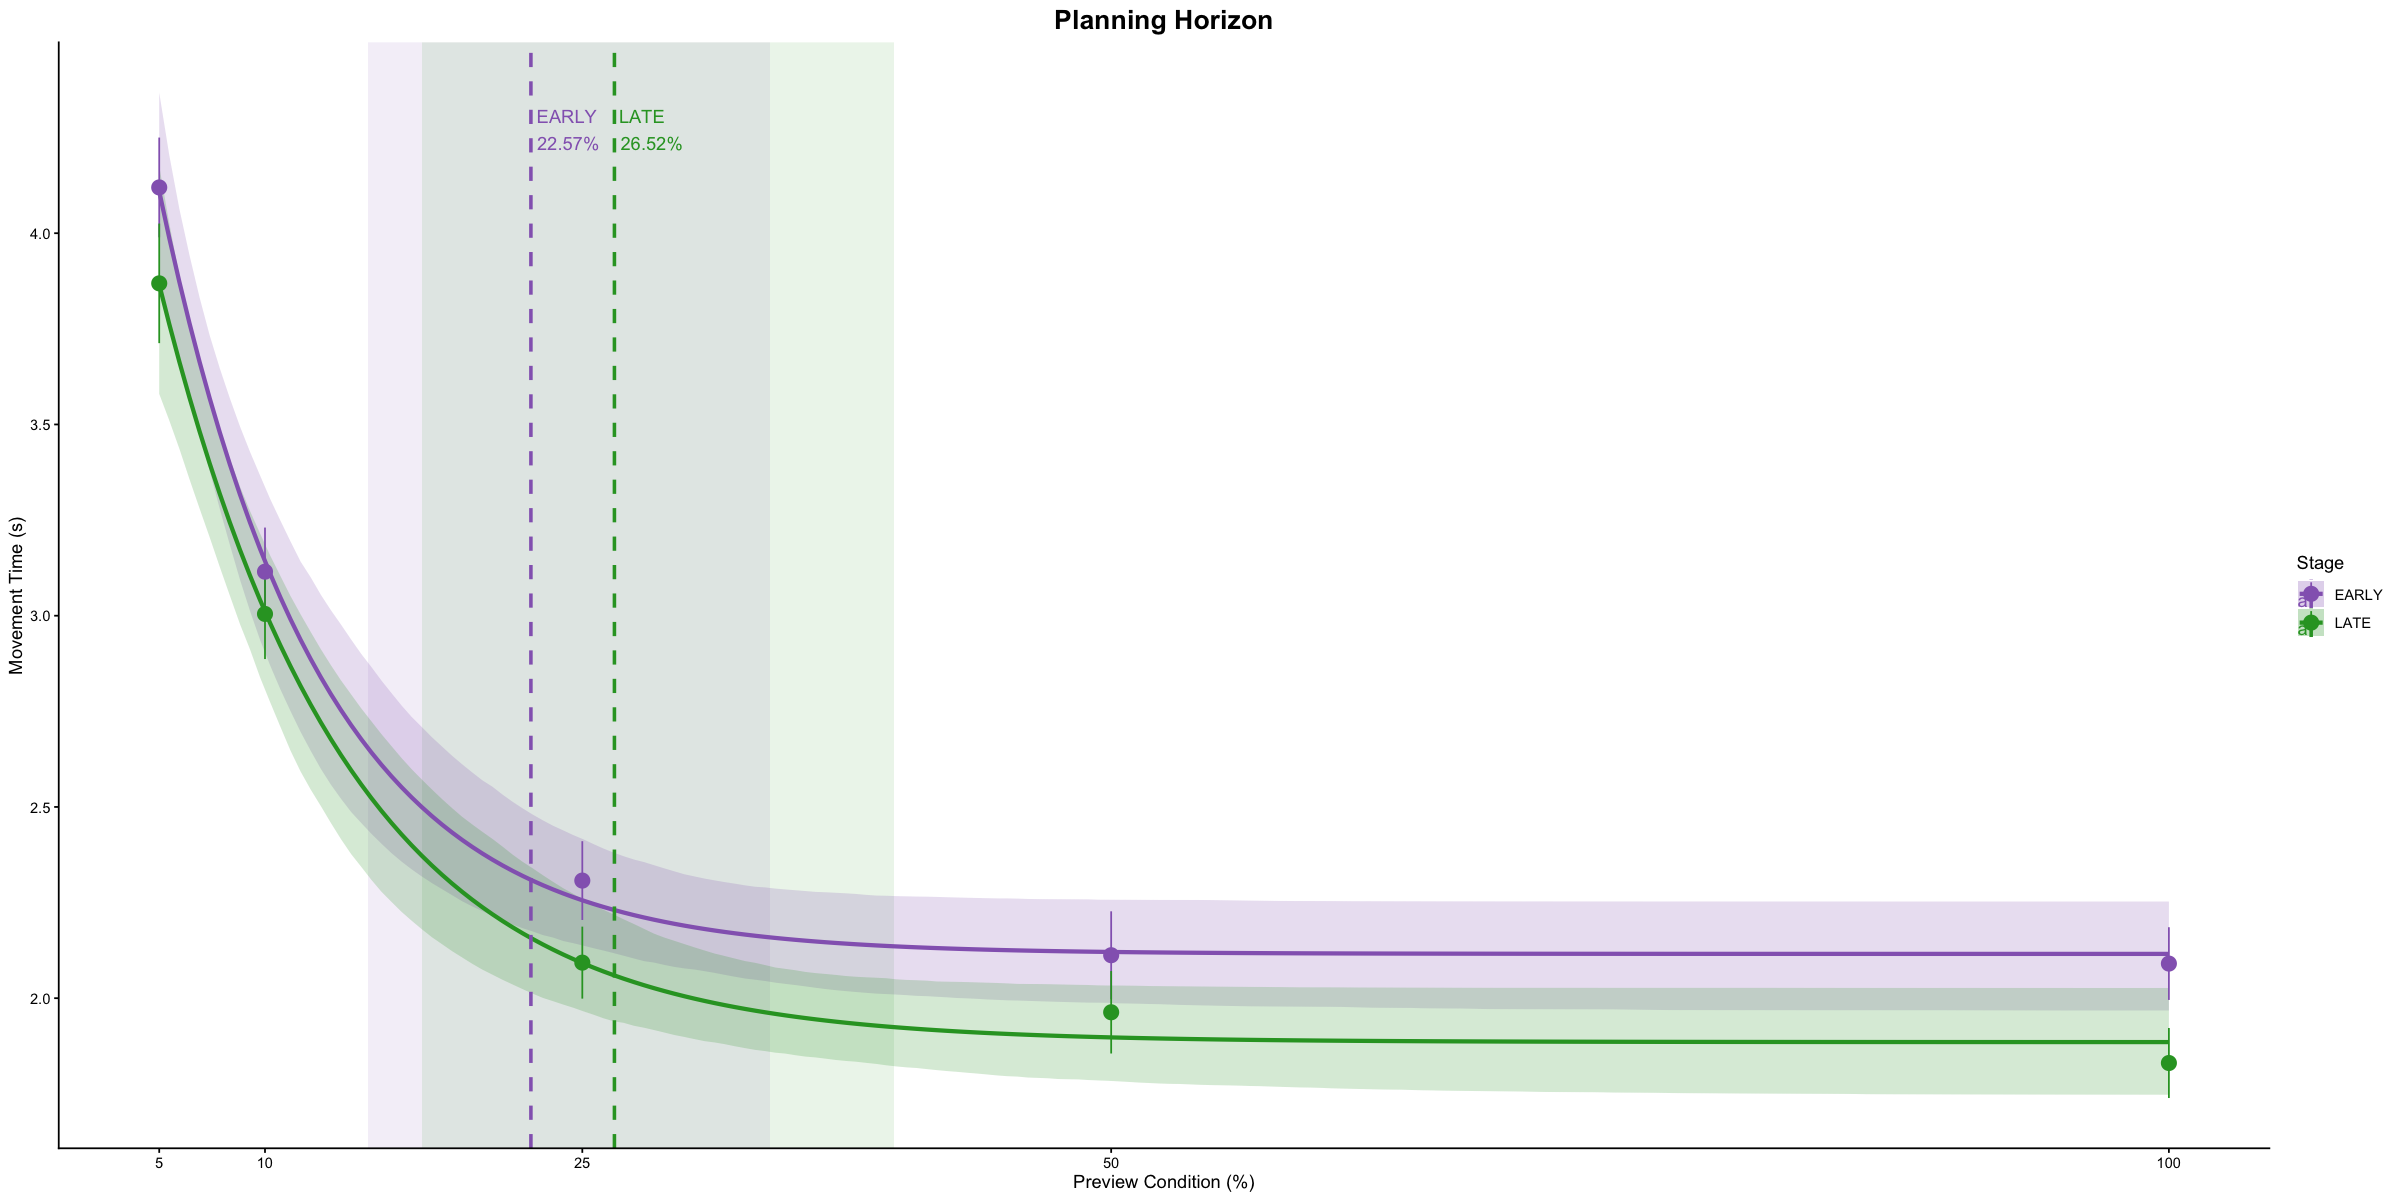

In [ ]:
df_horizon <- df %>% 
  filter(traj_type == "random", stage %in% c("EARLY", "LATE")) %>%
  mutate(condition = as.numeric(as.character(condition)),
         stage = factor(stage, levels = c("EARLY", "LATE")))

# Subject-level means
df_mean <- df_horizon %>%
  group_by(subject_id, condition, stage) %>%
  summarize(MT = mean(MT, na.rm = TRUE), .groups = "drop")

# Group-level means and SEM for plotting points
df_group <- df_mean %>%
  group_by(condition, stage) %>%
  summarize(
    mean_MT = mean(MT, na.rm = TRUE),
    sem_MT = sd(MT, na.rm = TRUE) / sqrt(n()),
    .groups = "drop"
  )

# MODEL & HORIZON FUNCTIONS
# Model: y = a * exp(-b * x) + c
# Horizon is x where (y - c) / a = eps --> exp(-b * x) = eps --> x = -log(eps) / b

eps_threshold <- 0.05

get_horizon <- function(b, eps = eps_threshold) {
  return(-log(eps) / b)
}

# Wrapper to safely fit the exponential model using Levenberg-Marquardt
fit_exp_model <- function(data) {
  tryCatch({
    # SSasymp formula: y = Asym + (R0 - Asym) * exp(-exp(lrc) * x)
    # This naturally maps to our equation: y = c + a * exp(-b * x)
    
    fit <- nls(MT ~ SSasymp(condition, Asym, R0, lrc), data = data)
    
    coefs <- coef(fit)
    
    # Map the SSasymp coefficients back to our a, b, c format
    c_val <- unname(coefs["Asym"])
    a_val <- unname(coefs["R0"] - coefs["Asym"])
    b_val <- unname(exp(coefs["lrc"])) # lrc is the natural log of the rate constant (b)
    
    return(c(a = a_val, b = b_val, c = c_val))
    
  }, error = function(e) {
    # If the curve is completely flat or perfectly linear, it will return NA
    return(c(a = NA, b = NA, c = NA)) 
  })
}


# BOOTSTRAPPING (N = 2000)

set.seed(42)
n_iter <- 2000

subjects <- unique(df_mean$subject_id)
x_grid <- seq(min(df_mean$condition), max(df_mean$condition), length.out = 200)

# Initialize with NA_real_ to prevent 0s from skewing the Confidence Intervals
early_h <- rep(NA_real_, n_iter) 
late_h  <- rep(NA_real_, n_iter)
early_curves <- matrix(NA, nrow = n_iter, ncol = 200)
late_curves <- matrix(NA, nrow = n_iter, ncol = 200)

print("Running Bootstrap...")

for (i in 1:n_iter) {
  # Sample subjects with replacement
  samp_subj <- sample(subjects, replace = TRUE)
  
  # Rebuild dataset based on sampled subjects
  samp_df <- tibble(subject_id = samp_subj) %>%
    left_join(df_mean, by = "subject_id", relationship = "many-to-many")
  
  # Fit Early
  fit_E <- fit_exp_model(samp_df %>% filter(stage == "EARLY"))
  if (!is.na(fit_E["b"])) {
    early_h[i] <- get_horizon(fit_E["b"])
    early_curves[i, ] <- fit_E["a"] * exp(-fit_E["b"] * x_grid) + fit_E["c"]
  }
  
  # Fit Late
  fit_L <- fit_exp_model(samp_df %>% filter(stage == "LATE"))
  if (!is.na(fit_L["b"])) {
    late_h[i] <- get_horizon(fit_L["b"])
    late_curves[i, ] <- fit_L["a"] * exp(-fit_L["b"] * x_grid) + fit_L["c"]
  }
}

# Calculate Confidence Intervals (ignoring NA failures)
early_h_clean <- na.omit(early_h)
late_h_clean <- na.omit(late_h)

early_ci <- quantile(early_h_clean, probs = c(0.025, 0.5, 0.975))
late_ci  <- quantile(late_h_clean, probs = c(0.025, 0.5, 0.975))

# Curve confidence bands
early_band <- apply(early_curves, 2, quantile, probs = c(0.025, 0.975), na.rm = TRUE)
late_band  <- apply(late_curves, 2, quantile, probs = c(0.025, 0.975), na.rm = TRUE)

# Difference testing
# Ensure we only diff pairs where BOTH models converged
valid_idx <- !is.na(early_h) & !is.na(late_h)
diffs <- late_h[valid_idx] - early_h[valid_idx]
diff_ci <- quantile(diffs, probs = c(0.025, 0.5, 0.975))


# MAIN FIT FOR PLOTTING
main_fit_E <- fit_exp_model(df_mean %>% filter(stage == "EARLY"))
main_fit_L <- fit_exp_model(df_mean %>% filter(stage == "LATE"))

main_h_E <- get_horizon(main_fit_E["b"])
main_h_L <- get_horizon(main_fit_L["b"])

df_curves_plot <- tibble(
  condition = rep(x_grid, 2),
  stage = factor(rep(c("EARLY", "LATE"), each = 200), levels = c("EARLY", "LATE")),
  y_fit = c(main_fit_E["a"] * exp(-main_fit_E["b"] * x_grid) + main_fit_E["c"],
            main_fit_L["a"] * exp(-main_fit_L["b"] * x_grid) + main_fit_L["c"]),
  ymin = c(early_band[1, ], late_band[1, ]),
  ymax = c(early_band[2, ], late_band[2, ])
)

df_horizons <- tibble(
  stage = factor(c("EARLY", "LATE"), levels = c("EARLY", "LATE")),
  horizon = c(main_h_E, main_h_L),
  ci_low = c(early_ci[1], late_ci[1]),
  ci_high = c(early_ci[3], late_ci[3])
)

# GGPLOT VISUALIZATION
custom_colors <- c("EARLY" = "#9467bd", "LATE" = "#2ca02c") # Equivalent to tab:purple and tab:green

p_horizon <- ggplot() +
  # Horizon CI Shaded Rectangles
  geom_rect(data = df_horizons,
            aes(xmin = ci_low, xmax = ci_high, ymin = -Inf, ymax = Inf, fill = stage),
            alpha = 0.1, inherit.aes = FALSE) +
  
  # Curve CI Bands
  geom_ribbon(data = df_curves_plot,
              aes(x = condition, ymin = ymin, ymax = ymax, fill = stage),
              alpha = 0.2) +
  
  # Fitted Exponential Lines
  geom_line(data = df_curves_plot,
            aes(x = condition, y = y_fit, color = stage), linewidth = 1.2) +
  
  # Group Mean ± SEM (Points with Error Bars)
  geom_pointrange(data = df_group,
                  aes(x = condition, y = mean_MT,
                      ymin = mean_MT - sem_MT, ymax = mean_MT + sem_MT, color = stage),
                  size = 0.8) +
  
  # Horizon Vertical Dashed Lines
  geom_vline(data = df_horizons,
             aes(xintercept = horizon, color = stage), linetype = "dashed", linewidth = 1) +
  
  # Horizon Text Annotations
  geom_text(data = df_horizons,
            aes(x = horizon, y = max(df_group$mean_MT) + 0.1, 
                label = sprintf("%s\n%.2f%%", stage, horizon), color = stage),
            vjust = 0, hjust = -0.1) +
  
  scale_color_manual(values = custom_colors) +
  scale_fill_manual(values = custom_colors) +
  scale_x_continuous(breaks = unique(df_group$condition)) +
  labs(title = "Planning Horizon", 
       x = "Preview Condition (%)", 
       y = "Movement Time (s)",
       color = "Stage", fill = "Stage") +
  theme_classic() +
  theme(plot.title = element_text(hjust = 0.5, size = 16, face = "bold"))

print(p_horizon)


# 6. STATISTICAL OUTPUT
cat("BOOTSTRAP RESULTS (N =", length(early_h_clean), "successful fits)\n")

# Print Early Horizon
cat("EARLY horizon (Point Estimate):", round(main_h_E, 2), "%\n")
cat("EARLY horizon 95% CI: [", round(early_ci[1], 2), ",", round(early_ci[3], 2), "]\n\n")

# Print Late Horizon
cat("LATE horizon (Point Estimate):", round(main_h_L, 2), "%\n")
cat("LATE horizon 95% CI:  [", round(late_ci[1], 2), ",", round(late_ci[3], 2), "]\n")

cat("\nDifference (LATE - EARLY):\n")
cat("Median: ", round(diff_ci[2], 2), "\n")
cat("95% CI: [", round(diff_ci[1], 2), ",", round(diff_ci[3], 2), "]\n")

# Safely check significance
if (any(is.na(diff_ci))) {
  cat("--> CONCLUSION: Could not compute significance (NAs present)\n")
} else if (diff_ci[1] > 0 | diff_ci[3] < 0) {
  cat("--> CONCLUSION: Significant difference\n")
} else {
  cat("--> CONCLUSION: Not significant\n")
}

## RQ2: How are learned motor skills represented?

### H2: Learned continuous skills benefit from a global representation of trajectory structure

We then asked whether learned skills benefit from a representation of the global trajectory structure.

To test this, we compared late performance on rotated against random trajectories. Across preview conditions, accuracy was higher ($t(285) = 16.9, p < .001$) and movement was smoother ($t(285) = 29.3, p < .001$) for rotated than random trajectories; however, movement times were slower ($t(285) = -4.66, p < .001$).

We thought participants were conducting the mental rotation process while finishing the rotated trajectories, so the movement was slower. Taken together, these results suggest that learned skills leverage the global structure of a trajectory to improve spatial accuracy, while at times shifting the speed–accuracy trade-off.

In [103]:
# HYPOTHESIS 2: Global Shape Transfer (Paired t-tests)

cat("RESEARCH QUESTION 2: GLOBAL SHAPE REPRESENTATION (TRANSFER)")
# Filter: LATE stage only, comparing rotated vs random
df_h2 <- df_stats %>%
  filter(stage == "LATE", traj_type %in% c("rotated", "random")) %>%
  mutate(traj_type = droplevels(traj_type))

cat("\n--- Hypothesis 2: LATE Stage (Rotated vs Random) ---\n")

for (dv in dvs) {
  cat(paste0("\n>>> Dependent Variable: ", dv, " <<<\n"))
  
  # Paired t-test
  stat_ttest <- df_h2 %>%
    t_test(as.formula(paste(dv, "~ traj_type")), paired = TRUE) %>%
    add_significance()
  
  # Cohen's d for Effect Size
  stat_effsize <- df_h2 %>%
    cohens_d(as.formula(paste(dv, "~ traj_type")), paired = TRUE)
  
  # Print cleanly formatted results
  print(stat_ttest %>% select(group1, group2, n1, n2, statistic, df, p, p.signif))
  cat("Effect Size (Cohen's d):", round(stat_effsize$effsize, 3), 
      paste0("(", stat_effsize$magnitude, ")\n"))
}

RESEARCH QUESTION 2: GLOBAL SHAPE REPRESENTATION (TRANSFER)
--- Hypothesis 2: LATE Stage (Rotated vs Random) ---

>>> Dependent Variable: MT <<<
# A tibble: 1 × 8
  group1 group2     n1    n2 statistic    df          p p.signif
  <chr>  <chr>   <int> <int>     <dbl> <dbl>      <dbl> <chr>   
1 random rotated   286   286     -4.66   285 0.00000492 ****    
Effect Size (Cohen's d): -0.275 (small)

>>> Dependent Variable: ERROR <<<
# A tibble: 1 × 8
  group1 group2     n1    n2 statistic    df        p p.signif
  <chr>  <chr>   <int> <int>     <dbl> <dbl>    <dbl> <chr>   
1 random rotated   286   286      16.9   285 8.17e-45 ****    
Effect Size (Cohen's d): 0.998 (large)

>>> Dependent Variable: LDJ <<<
# A tibble: 1 × 8
  group1 group2     n1    n2 statistic    df        p p.signif
  <chr>  <chr>   <int> <int>     <dbl> <dbl>    <dbl> <chr>   
1 random rotated   286   286     -29.3   285 8.07e-88 ****    
Effect Size (Cohen's d): -1.73 (large)


# Conclusion

Continuous skill learning reflects modest general improvements in planning and execution but substantial trajectory-specific gains that benefit from improved predictions of upcoming movements grounded in the trajectory’s global structure.  Together, these findings extend principles derived from discrete, sequential learning to real-world, continuous motor skills.